# Single-Subject Model Evaluation

Subject-keyed views of the LORO cached predictions.

1. **Per-subject performance** — LORO fold mean per model, ranked by an anchor model.
2. **Subject specificity** — does the prediction match *its* subject's truth more than other subjects' truths at the same region?
3. **Spatial specificity** — does the prediction match its *region*'s truth more than the subject's other regions' truths?

## Table of Contents

- Notebook Configuration
- Shared Reconstruction
- Section 1 — Per-Subject Performance
- Section 2 — Subject Specificity
- Section 3 — Spatial Specificity


In [1]:
from pathlib import Path
import sys
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
%matplotlib inline

import importlib
import src.eval_utils.eval_style as eval_style
import src.eval_utils.eda_core as eda_core
import src.eval_utils.eval_population as eval_population
import src.eval_utils.eval_single_subject as eval_single_subject
importlib.reload(eval_style)
importlib.reload(eda_core)
importlib.reload(eval_population)
importlib.reload(eval_single_subject)
from src.eval_utils.eval_style import *
from src.eval_utils.eval_population import *
from src.eval_utils.eval_single_subject import *


## Notebook Configuration

Global / cross-section knobs in the next cell. Per-section knobs (LORO coverage, anchor model, percentile shading, illustrative subjects, specificity) live in mini-config cells immediately above their use sites — edit those in place for fluid in-notebook iteration.


In [3]:
# === Global config ===
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    cache_root='out/loro_subject_cache_c',  # 'out/loro_subject_cache_c' (centroids) | 'out/loro_subject_cache_cv' (centroids_and_volumes)
    gene_scope='allgenes',
)
print('analysis scope:', CFG.gene_scope)

# Shared across the entire notebook ↓
MODELS                       = ['naive', 'dlam', 'plam']
N_JOBS                       = 16
CACHE_GLOBAL_TABLES          = True
FORCE_REBUILD_GLOBAL_TABLES  = False

EVAL_GENE_LIST_PATH          = None  # path | None for all genes
VIEW_SUBSET = dict(
    genes=None, subjects=None, tissues=None,
    region_groups=None, sex=None, age=None,
)

DEFAULT_METRIC               = 'pearson_r'   # pearson_r | spearman_r | r2 | rmse


analysis scope: allgenes


## Shared Reconstruction

`PREPOST` + canonical wide tables + filtered view used by Sections 2 & 3.


In [4]:
PREPOST = prepare_pre_post_harmonization_cached(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])

[prepost_cache] hit  notebooks/cache/prepost/9bb11880a6c1bde4.pkl  (10426.1 MB)
subjects: 318
genes: 13618
parcels: 150


In [5]:
truth_df, pred_dfs, global_manifest = build_global_prediction_tables(
    cfg=CFG,
    prepost=PREPOST,
    models=MODELS,
    cache=CACHE_GLOBAL_TABLES,
    force_rebuild=FORCE_REBUILD_GLOBAL_TABLES,
    n_jobs=N_JOBS,
)
print({model: df.shape for model, df in pred_dfs.items()})

{'naive': (2869, 13636), 'dlam': (2869, 13636), 'plam': (2869, 13636)}


In [6]:
subject_view = make_prediction_eval_view(
    truth_df=truth_df,
    pred_dfs=pred_dfs,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    models=MODELS,
    **VIEW_SUBSET,
)

## Section 1 — Per-Subject Performance

Per-subject LORO mean per model. Subjects are sorted by the **anchor** model's mean; every other model is plotted on the same x positions for direct read-off.

Set `SPARSIFY=N` to keep one subject at every `100/N`-th percentile of the anchor model. The selected subjects come back as `band_subjects` for downstream illustrative-subject work.


In [7]:
# Section 1 config — per-subject performance & illustrative scatters
FOLD_COMBO_COVERAGE_MIN      = 5
FOLD_COMBO_COVERAGE_MAX      = 12
PERFORMANCE_FOLD_METRIC      = 'pearson_r'   # column in fold_perf_df

ANCHOR_MODEL                 = 'dlam'        # ranked / shaded / illustrated against this model
SPARSIFY                     = 100           # one subject per (100/SPARSIFY)% of anchor distribution; None = all
BOTTOM_QUANTILE              = 0.20          # static fallback red-shade leftmost % (None = off)
DYNAMIC_BOTTOM_QUANTILE      = True          # override BOTTOM_QUANTILE with anchor>naive crossover
TOP_QUANTILE                 = None          # green-shade rightmost % (None = off)


In [8]:
fold_perf_df, combo_df = compute_fold_combo_metrics_from_cache(
    CFG,
    PREPOST,
    coverage_min=FOLD_COMBO_COVERAGE_MIN,
    coverage_max=FOLD_COMBO_COVERAGE_MAX,
    models=MODELS,
    eval_gene_path=EVAL_GENE_LIST_PATH,
    n_jobs=N_JOBS,
)
print('fold_perf_df:', fold_perf_df.shape)
print('combo_df:', combo_df.shape)

fold_perf_df: (8607, 16)
combo_df: (4509, 17)


In [9]:
subject_perf = compute_subject_performance(
    fold_perf_df,
    metric=PERFORMANCE_FOLD_METRIC,
    models=MODELS,
)
print('subject_perf:', subject_perf.shape)
display(
    subject_perf.groupby('model', as_index=False)
    .agg(n_subjects=('subject', 'nunique'),
         mean=('mean', 'mean'),
         median=('mean', 'median'),
         worst=('mean', 'min'),
         best=('mean', 'max'))
)

subject_perf: (954, 6)


,model,n_subjects,mean,median,worst,best
0,dlam,318,0.872995,0.895218,0.511890,0.971234
1,naive,318,0.853850,0.851597,0.781220,0.898533
2,plam,318,0.870838,0.880141,0.575761,0.950043


In [10]:
# Percentile-band subject selection anchored on the chosen model.
band_subjects = select_subjects_by_percentile(
    subject_perf,
    metric=PERFORMANCE_FOLD_METRIC,
    model=ANCHOR_MODEL,
    n_bands=int(SPARSIFY) if SPARSIFY else 100,
)
display(band_subjects)

,selection_index,percentile_anchor,subject,model,mean,std,n_folds,percentile_rank,target_value
0,0,0.5,GTEX-14E7W,dlam,0.529821,0.066691,9,0.943396,0.525914
1,1,1.5,GTEX-13SLW,dlam,0.540416,0.056950,10,1.886792,0.539632
2,2,2.5,GTEX-13OVH,dlam,0.553144,0.040911,9,2.830189,0.552679
3,3,3.5,GTEX-1H1DG,dlam,0.566899,0.041655,11,3.773585,0.567501
4,4,4.5,GTEX-15DCD,dlam,0.599219,0.039159,11,4.716981,0.599508
...,...,...,...,...,...,...,...,...,...
95,95,95.5,GTEX-1E1VI,dlam,0.958774,0.016217,12,95.597484,0.958541
96,96,96.5,GTEX-13FHP,dlam,0.959114,0.036605,7,96.540881,0.959094
97,97,97.5,GTEX-ZYFD,dlam,0.960895,0.015554,9,97.484277,0.960911
98,98,98.5,GTEX-11ZVC,dlam,0.961785,0.008368,6,98.427673,0.961950


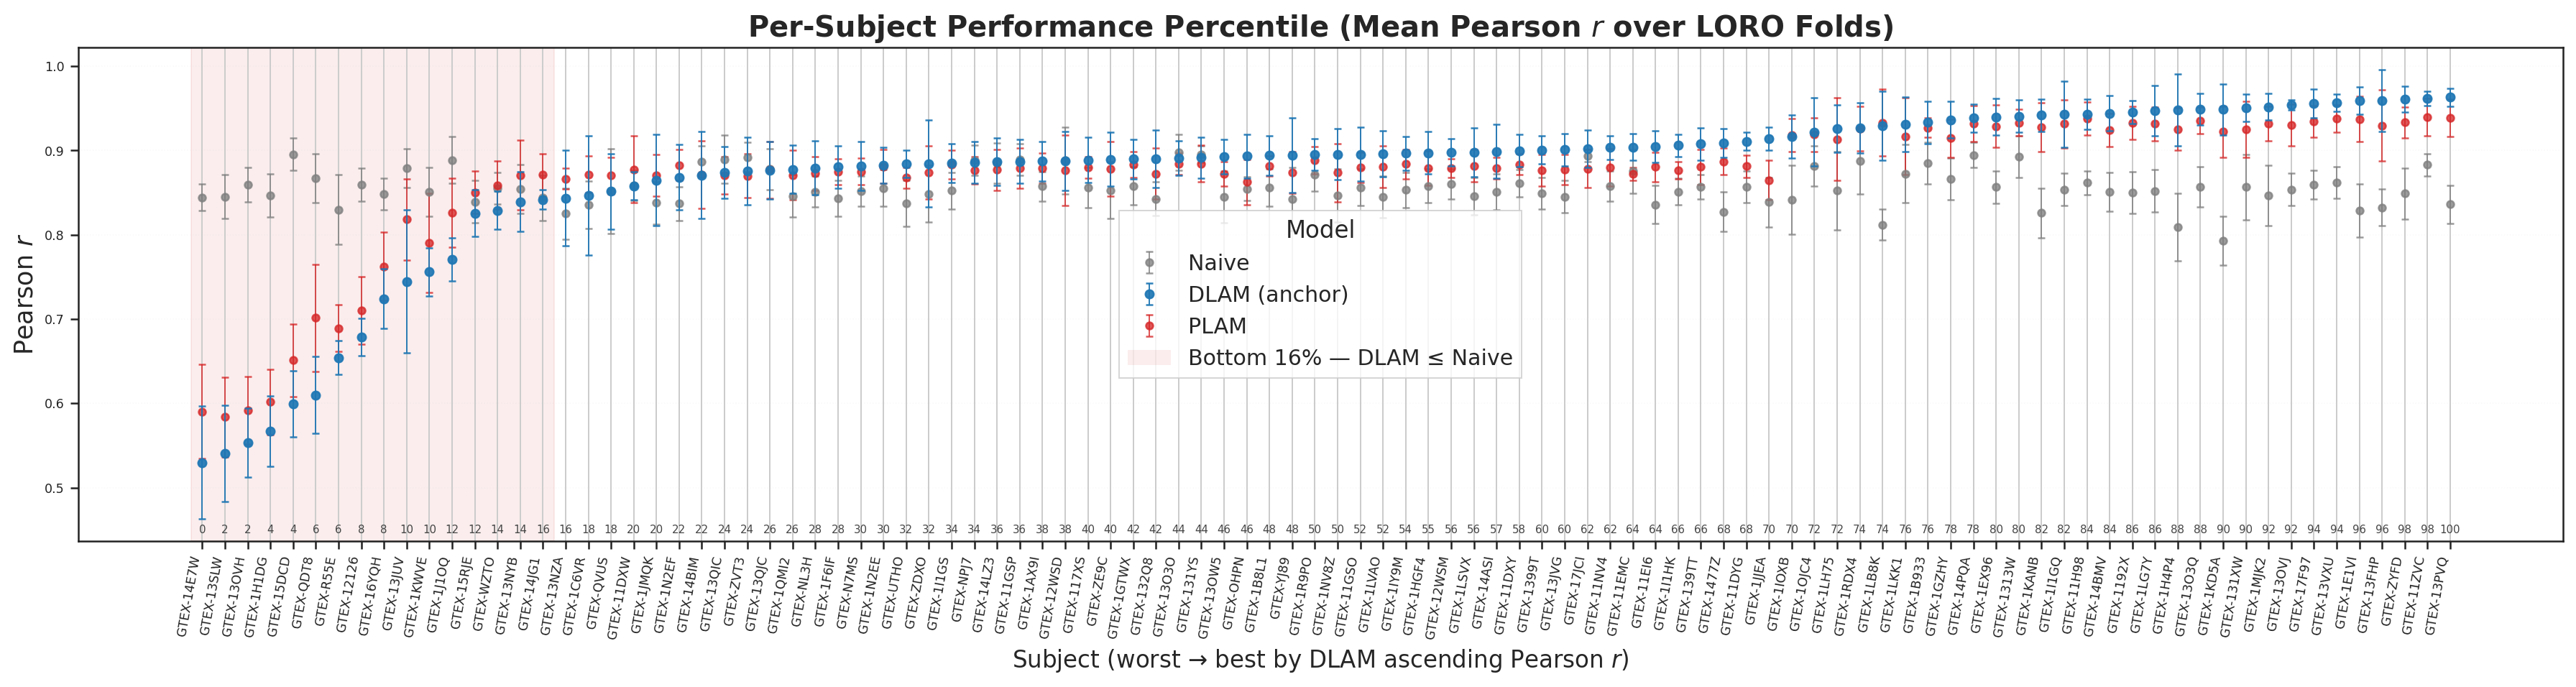

In [11]:
fig, ax, ranked_summary = plot_subject_performance_ranked(
    subject_perf,
    metric=PERFORMANCE_FOLD_METRIC,
    models=MODELS,
    sparsify=SPARSIFY,
    anchor_model=ANCHOR_MODEL,
    bottom_quantile=BOTTOM_QUANTILE,
    dynamic_bottom_quantile=DYNAMIC_BOTTOM_QUANTILE,
    top_quantile=TOP_QUANTILE,
)

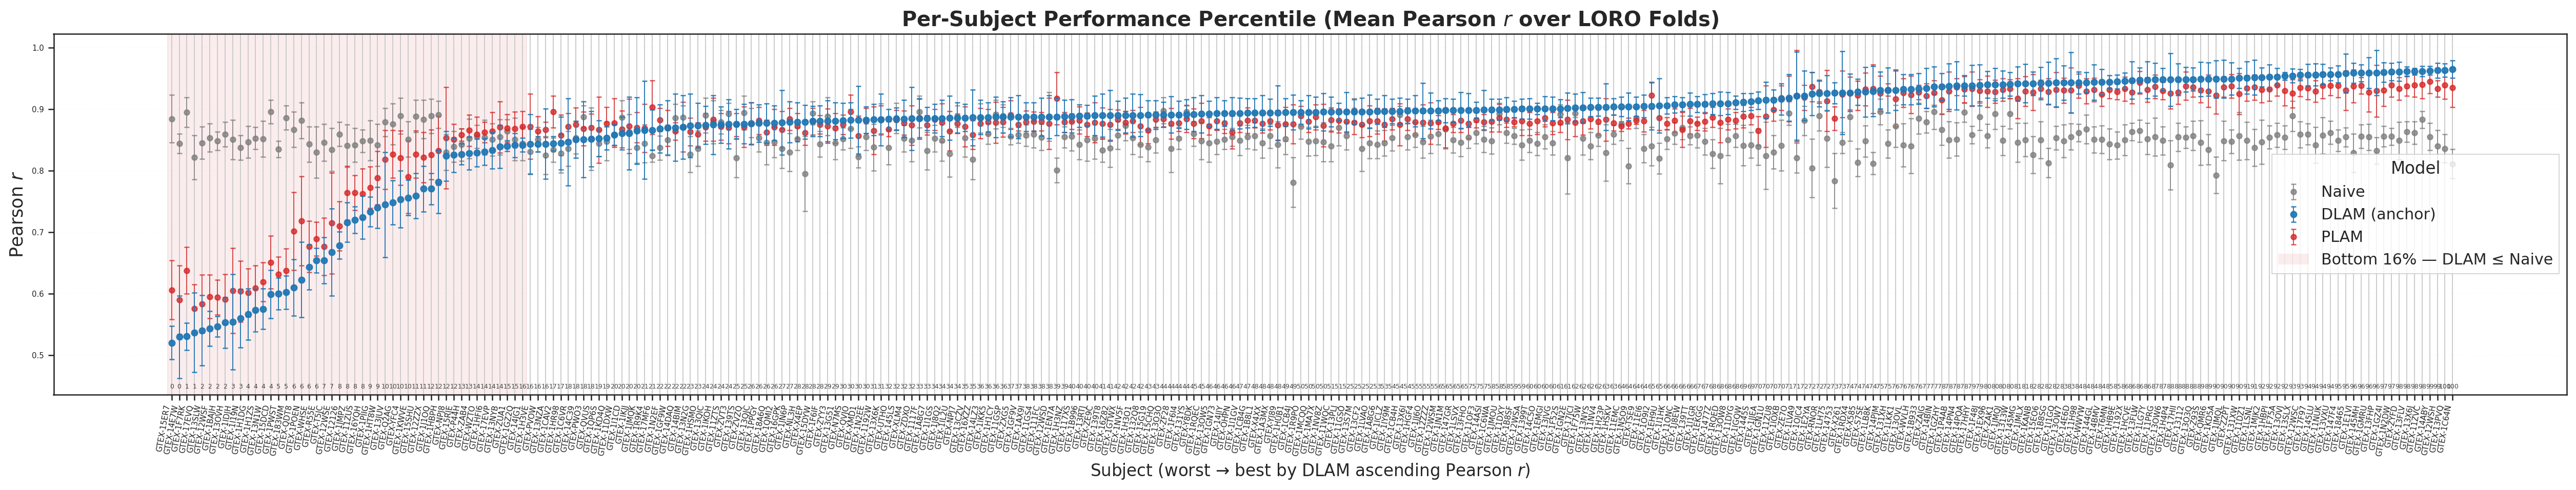

In [12]:
fig, ax, ranked_summary = plot_subject_performance_ranked(
    subject_perf,
    metric=PERFORMANCE_FOLD_METRIC,
    models=MODELS,
    sparsify=300,
    anchor_model=ANCHOR_MODEL,
)

### Illustrative subjects (10 / 50 / 90 percentile)

Truth-vs-prediction scatter for one subject at each performance percentile of the anchor model. Color = GTEx tissue.


In [23]:
# Illustrative-subject scatter config
ILLUSTRATIVE_PERCENTILES     = [5, 50, 95]
ILLUSTRATIVE_FIGSIZE         = (7.0, 6.0)
ILLUSTRATIVE_ANNOTATE_METRIC = 'pearson_r'   # per-category metric in legend; None = off


In [24]:
# Pick subjects nearest to ILLUSTRATIVE_PERCENTILES from band_subjects (or compute on-the-fly).
if 'band_subjects' in globals() and not band_subjects.empty:
    pct = band_subjects['percentile_anchor'].astype(float).round().astype(int)
    pct_picks = band_subjects.iloc[[(pct - p).abs().idxmin() for p in ILLUSTRATIVE_PERCENTILES]]
else:
    pct_picks = select_subjects_by_percentile(
        subject_perf, metric=PERFORMANCE_FOLD_METRIC, model=ANCHOR_MODEL,
        percentiles=[p / 100.0 for p in ILLUSTRATIVE_PERCENTILES],
    )

def _suptitle(fig, row, suffix=''):
    fig.suptitle(
        f"{model_label(ANCHOR_MODEL)} vs Truth — Subject {row['subject']} — "
        f"p{float(row['percentile_anchor']):.0f} "
        f"({format_legend_label(PERFORMANCE_FOLD_METRIC)} mean={float(row['mean']):.3f})"
        + (f" — {suffix}" if suffix else ''),
        fontsize=font_size('xxl'), y=0.97,
    )

def _make_subview(row, gene_list_path):
    return make_prediction_eval_view(
        truth_df=truth_df, pred_dfs=pred_dfs,
        eval_gene_list_path=gene_list_path,
        models=[ANCHOR_MODEL], subjects=[row['subject']],
        **{k: v for k, v in VIEW_SUBSET.items() if k != 'subjects'},
    )


##### View A — colored by region

Full gene scope. One figure per illustrative-percentile subject.


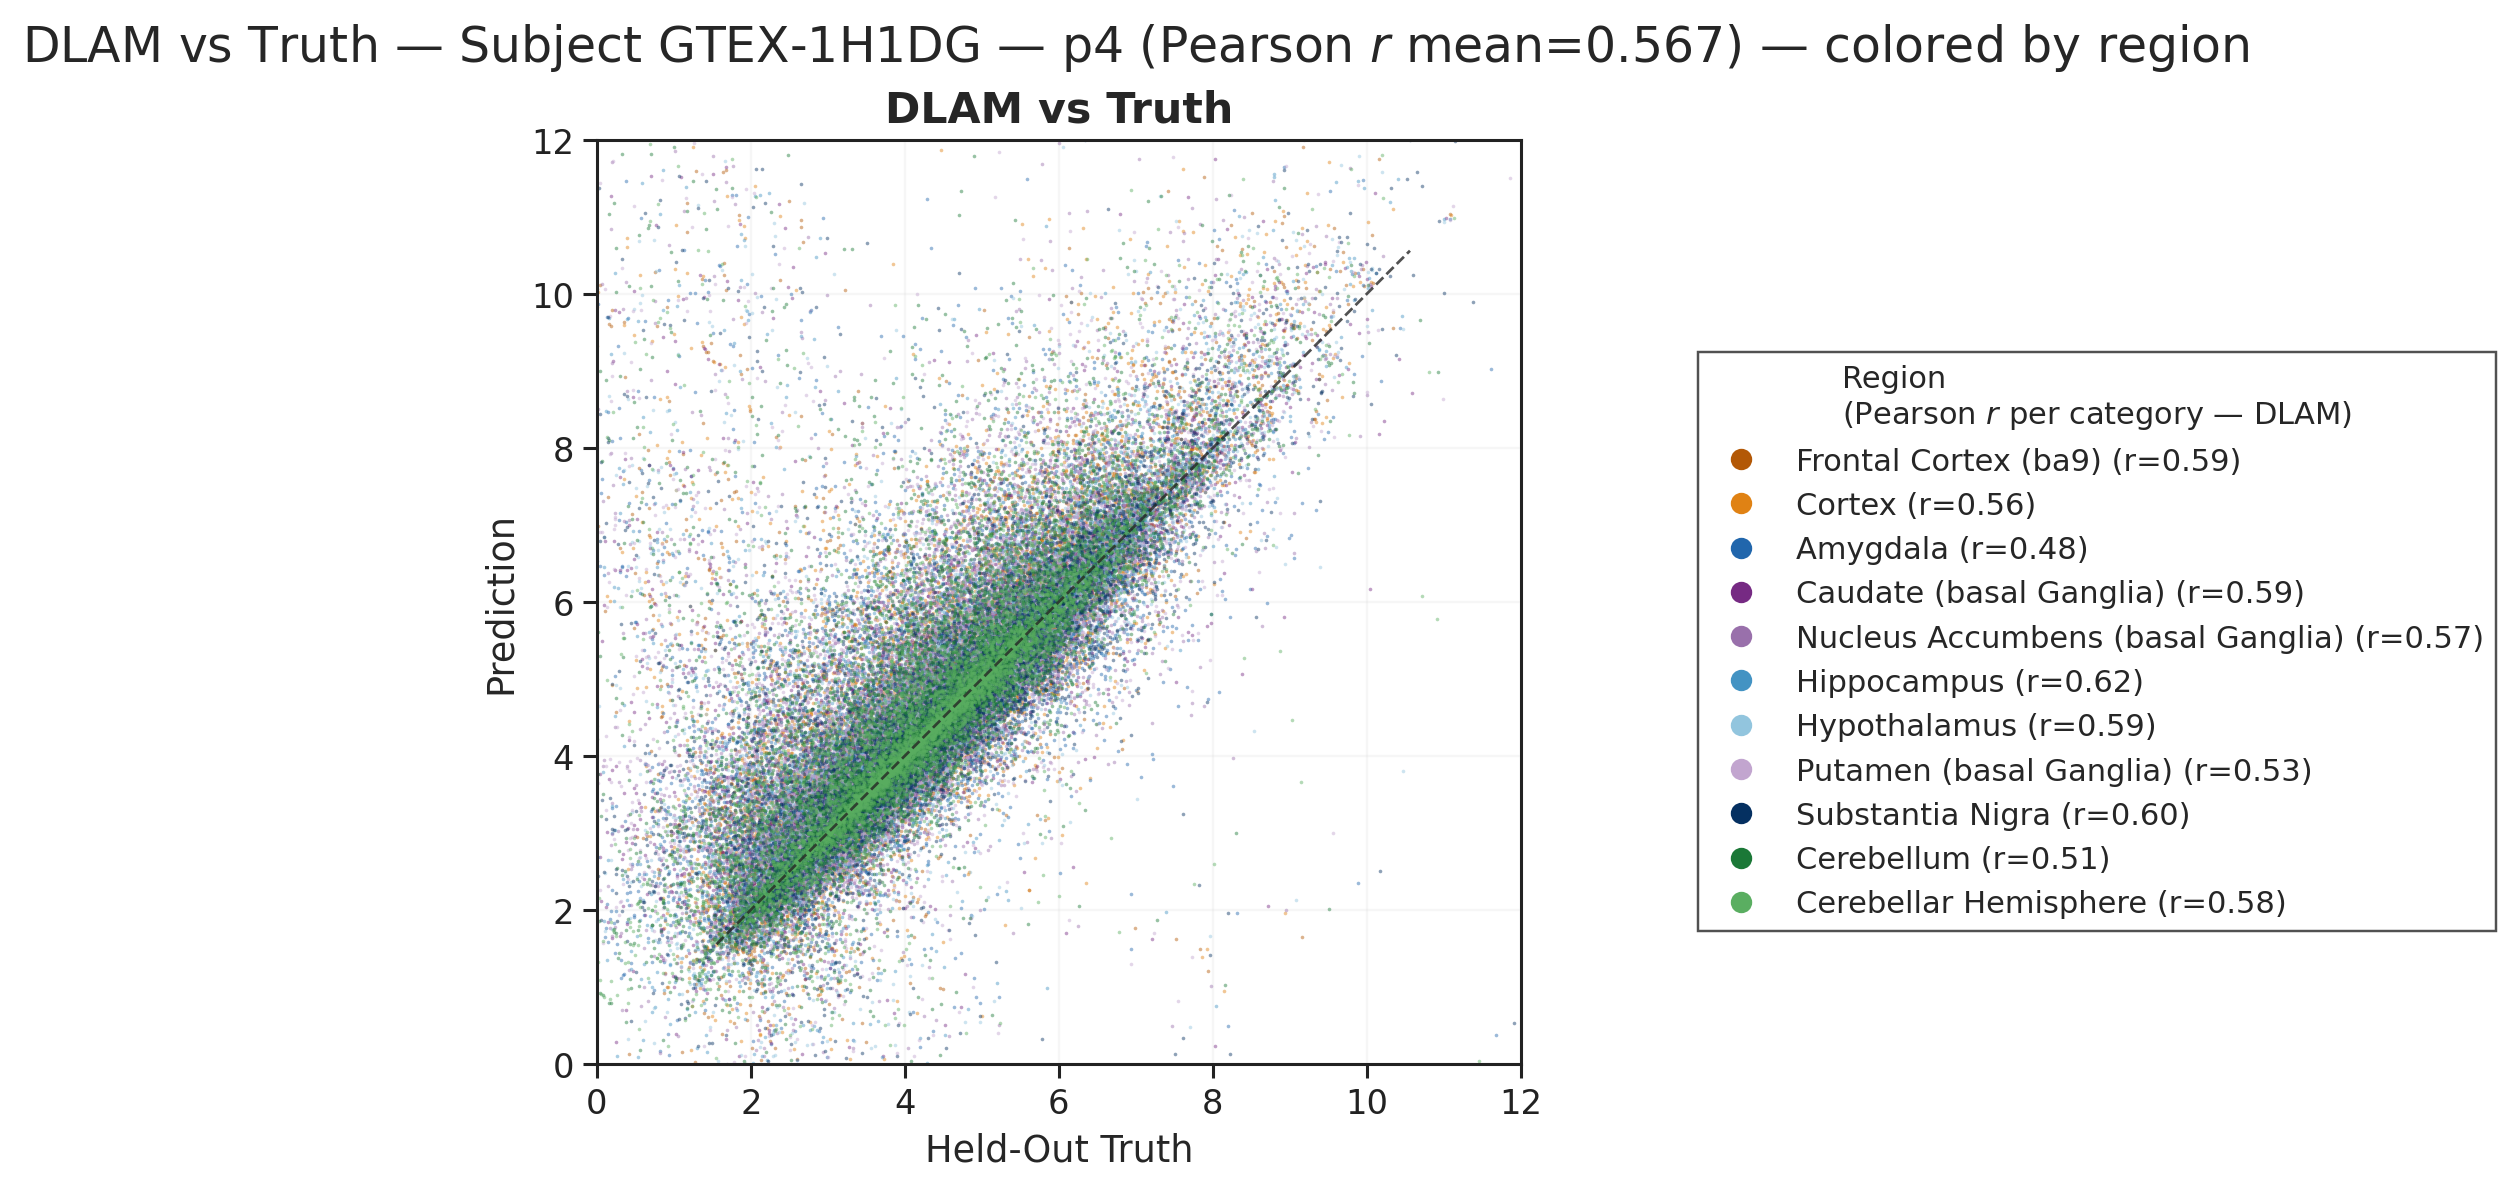

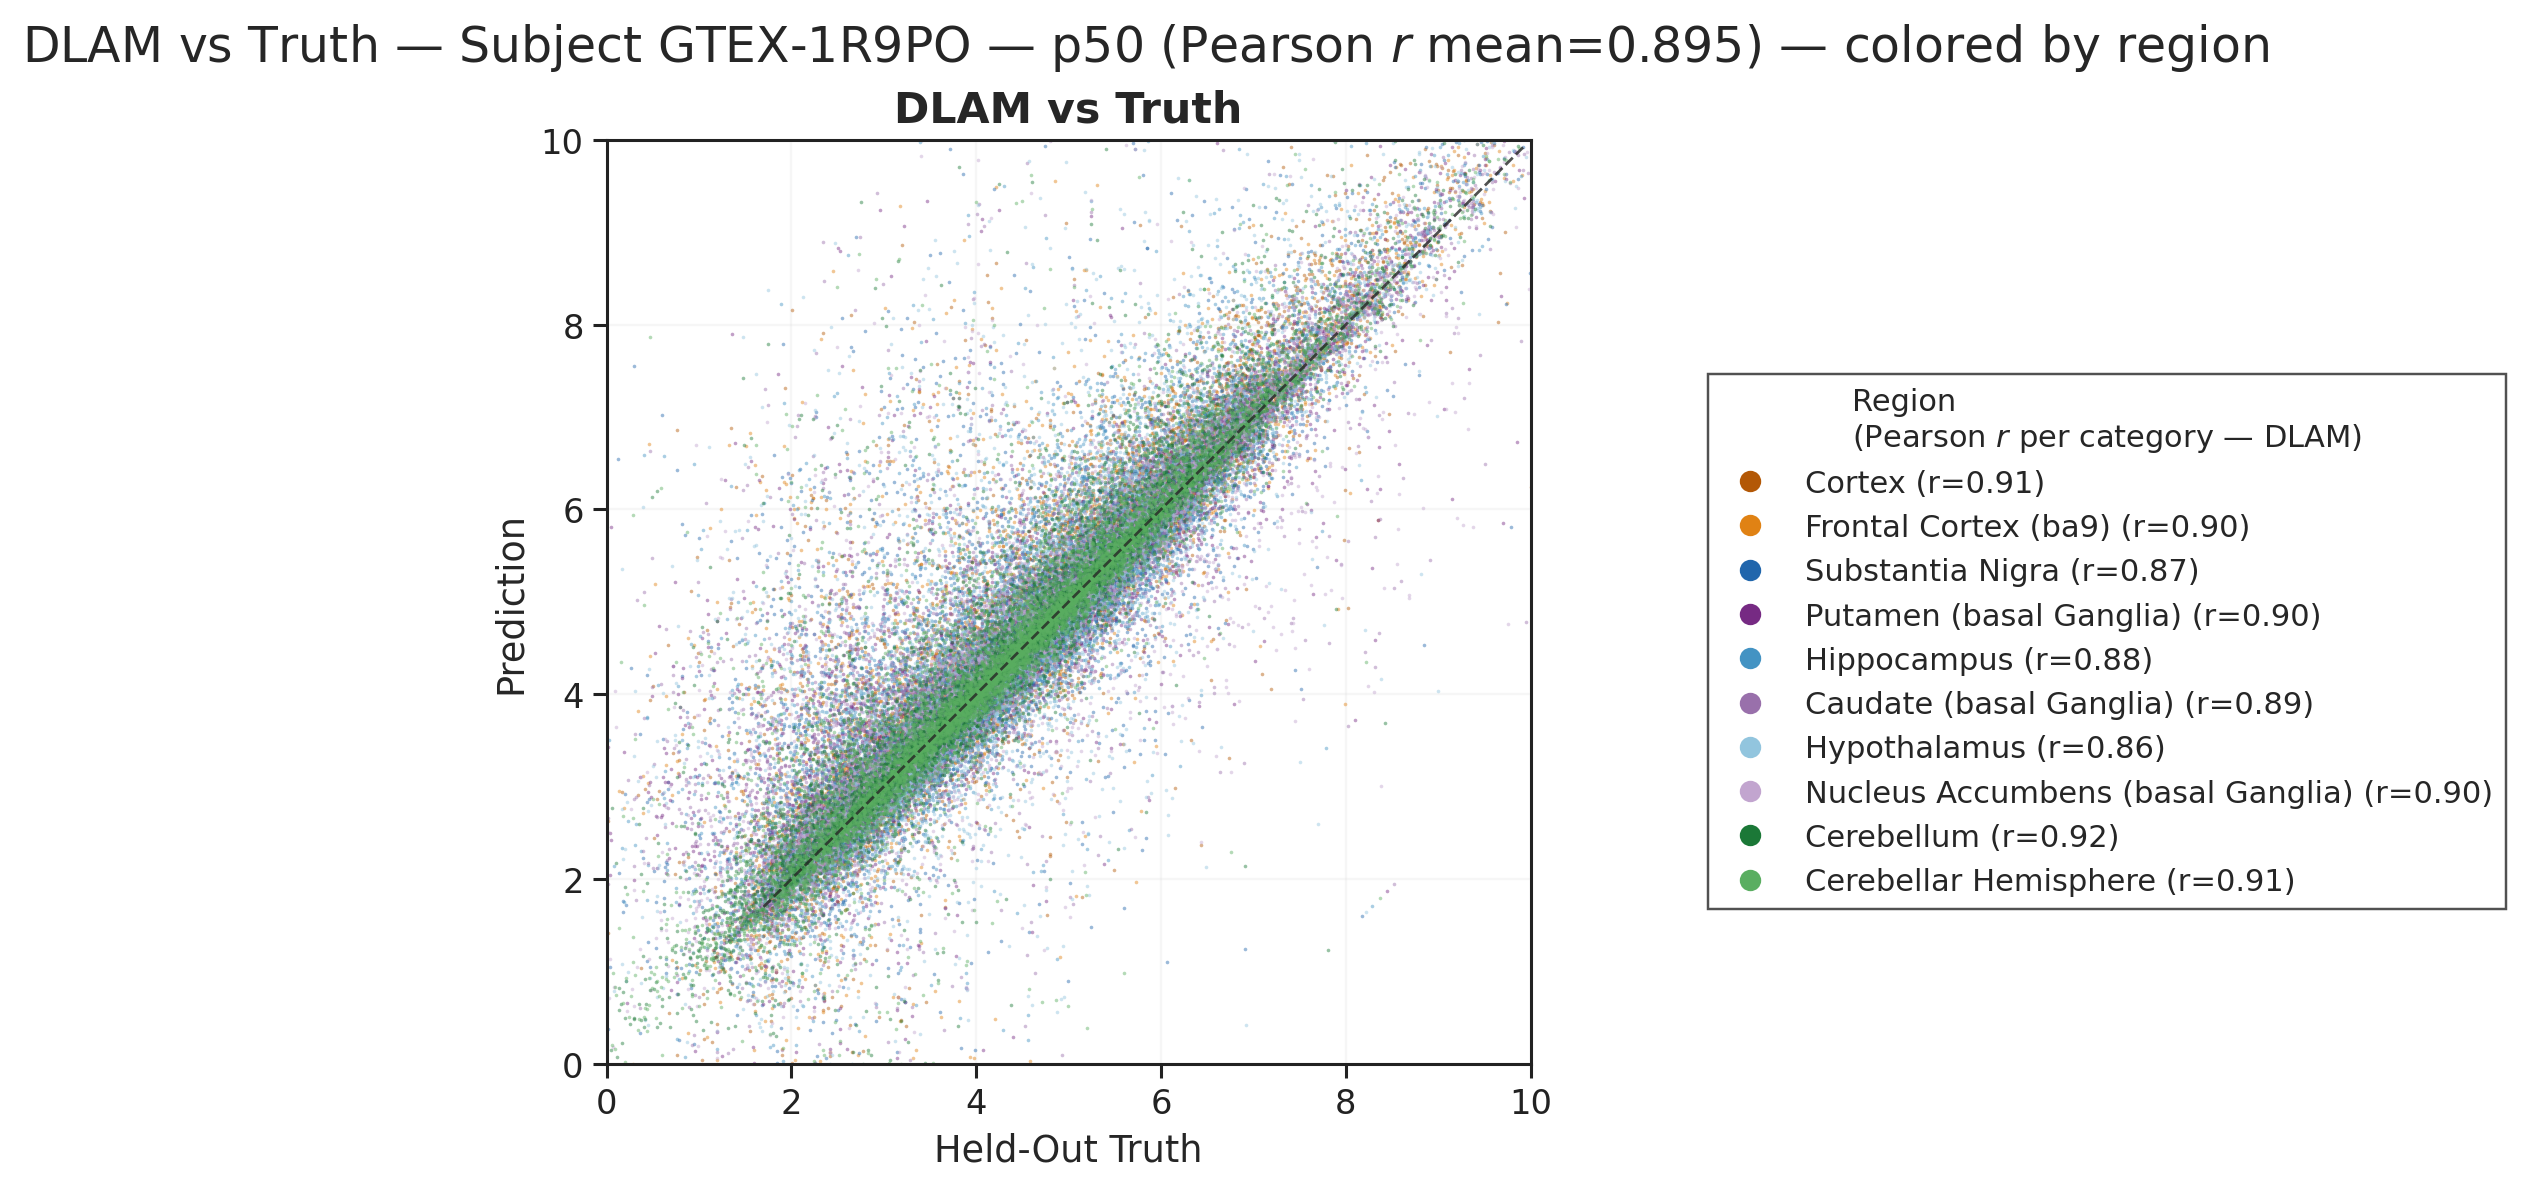

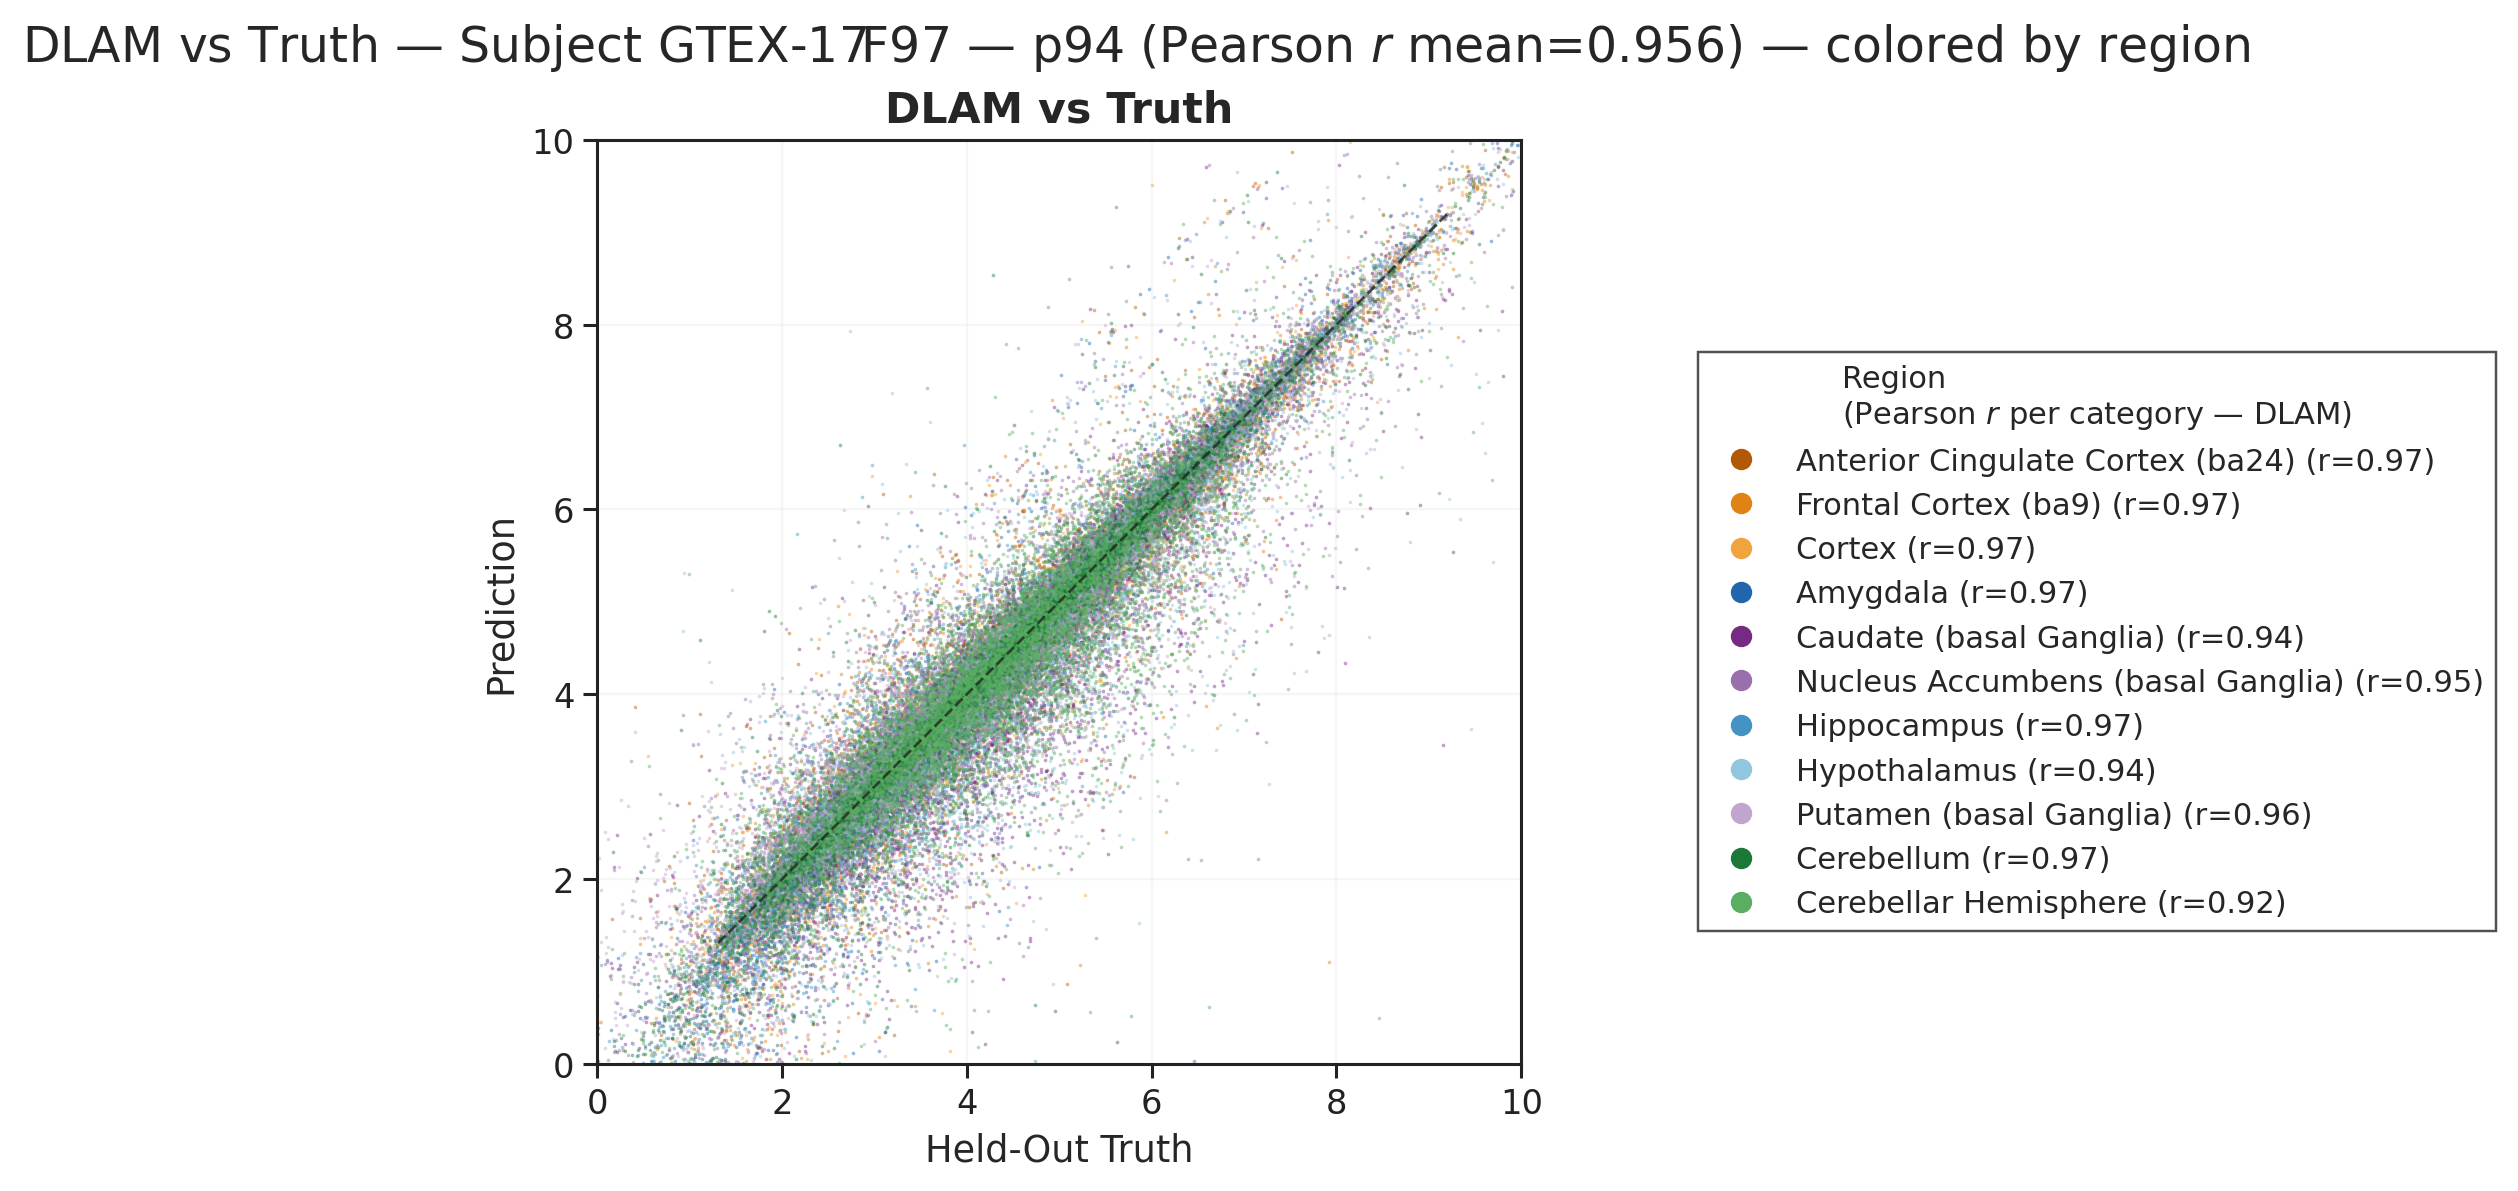

In [25]:
for _, row in pct_picks.iterrows():
    sub_view = _make_subview(row, EVAL_GENE_LIST_PATH)
    fig, axes = plot_global_prediction_scatter(
        sub_view,
        color_by='region',
        figsize=ILLUSTRATIVE_FIGSIZE,
        annotate_metric_in_legend=ILLUSTRATIVE_ANNOTATE_METRIC is not None,
        annotation_metric=ILLUSTRATIVE_ANNOTATE_METRIC or 'pearson_r',
    )
    _suptitle(fig, row, 'colored by region')


##### View B — colored by gene (HVG subset)

Same 3 subjects, restricted to `ILLUSTRATIVE_GENE_LIST_HVG`. Top-N genes get the categorical palette; the rest render as 'Other'.


In [37]:
# View B (gene-stratified) restricts the scatter to a gene list path/basename.
ILLUSTRATIVE_GENE_LIST_HVG   = 'richiardi2015'
ILLUSTRATIVE_GENE_TOP_N      = 10            # top-N genes shown in the legend

# View C (focus gene) isolates a single gene's panel from view B.
ILLUSTRATIVE_FOCUS_GENE      = 'CRYBA2'

# Views B/C/D share a larger canvas than View A's ILLUSTRATIVE_FIGSIZE.
ILLUSTRATIVE_FIGSIZE_BC      = (11.0, 9.0)
# Marker size for the gene-sublist views (B/C/D); default scatter point_size is 1.4,
# tuned for 100k-point population plots — far too small for these subsetted panels.
ILLUSTRATIVE_POINT_SIZE_BC   = 30.0


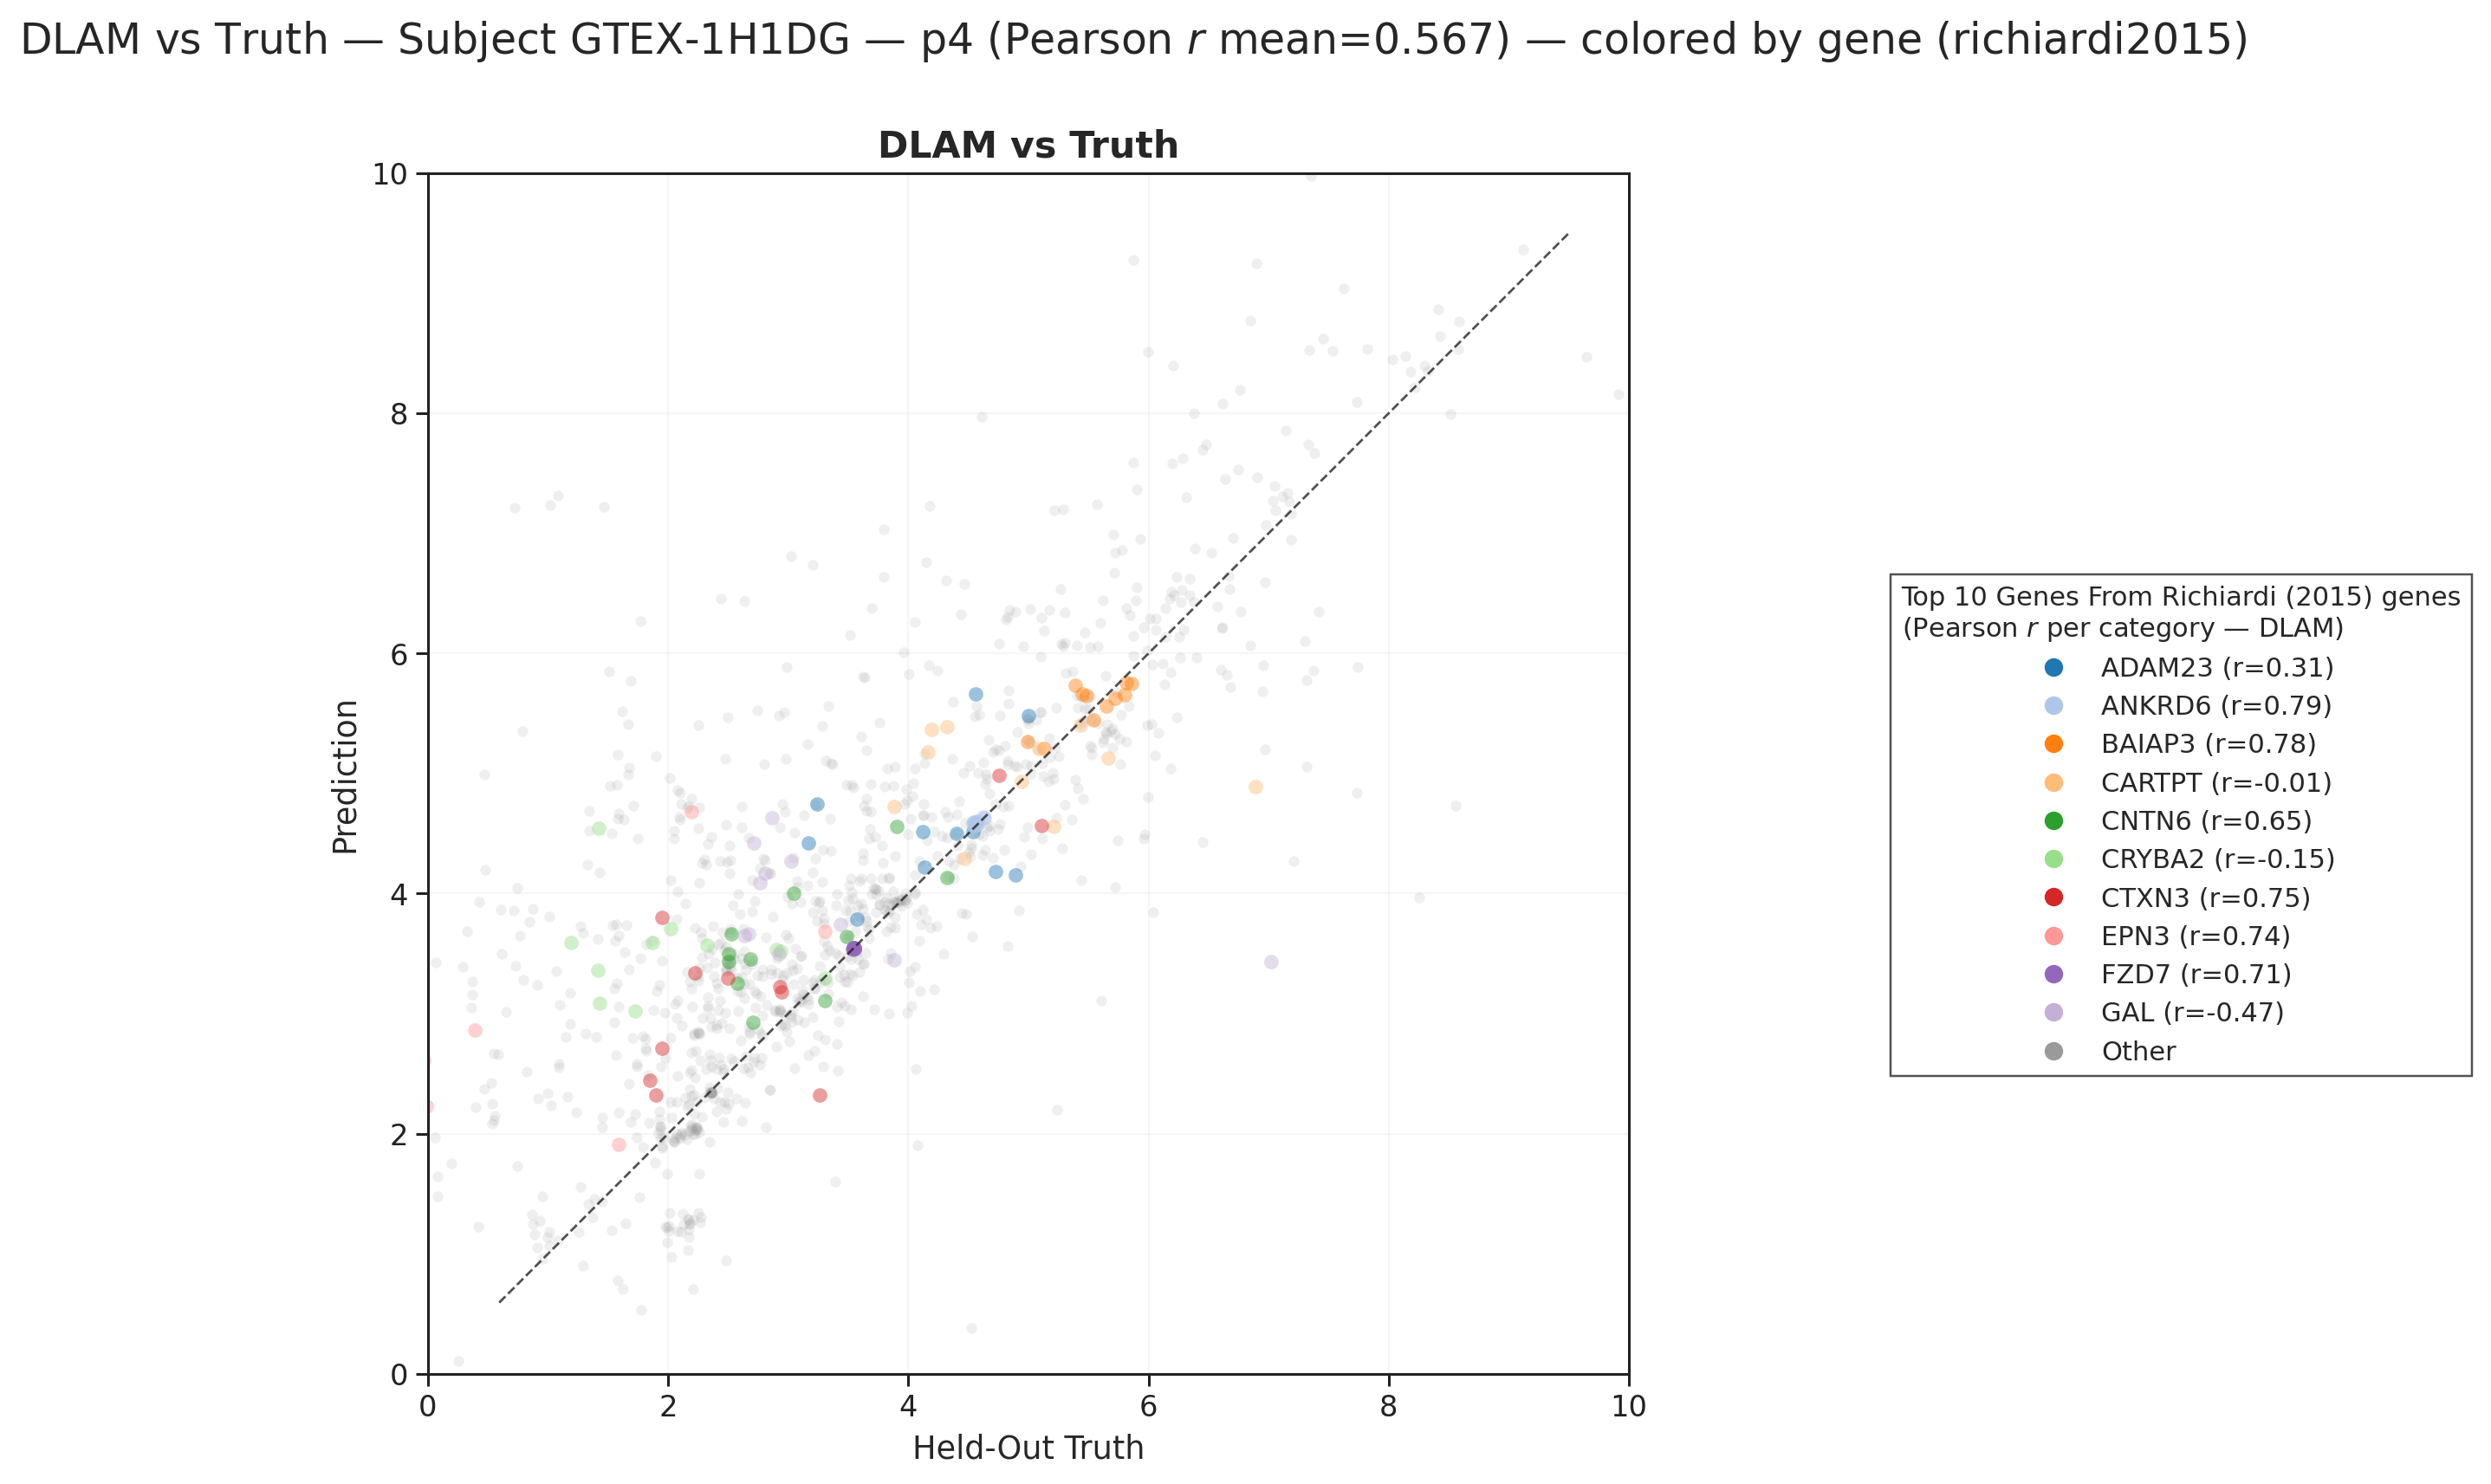

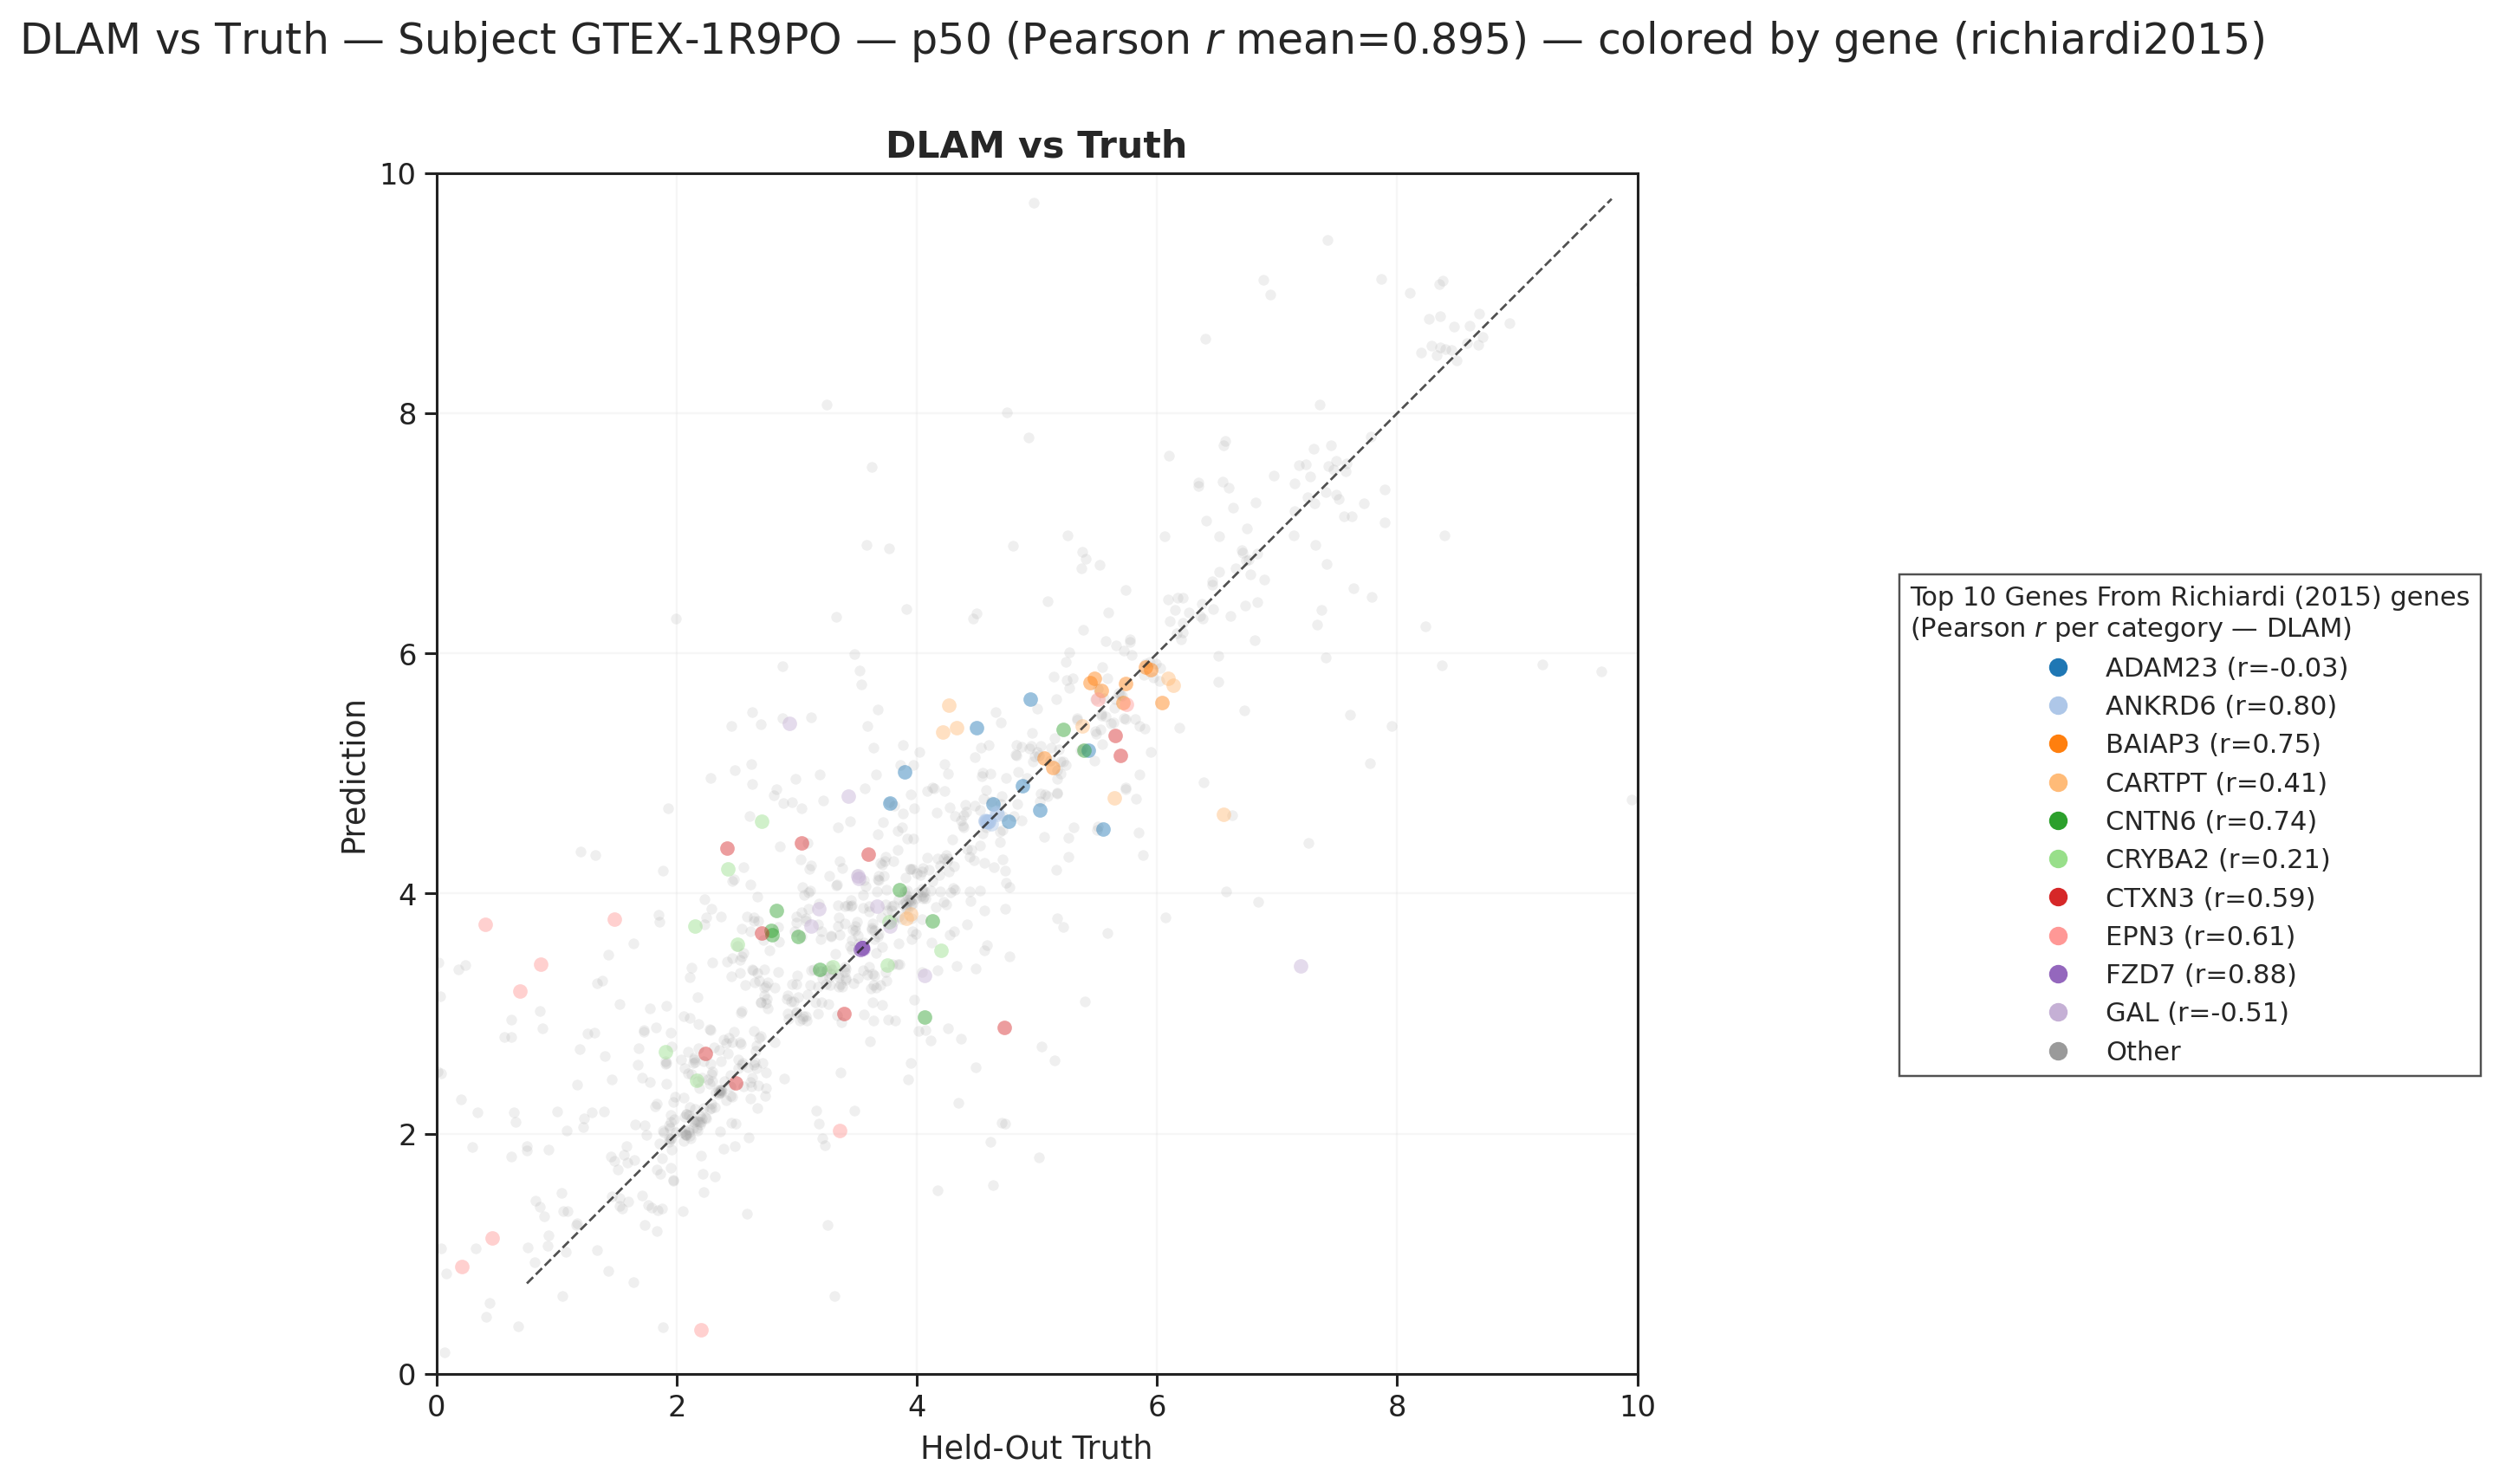

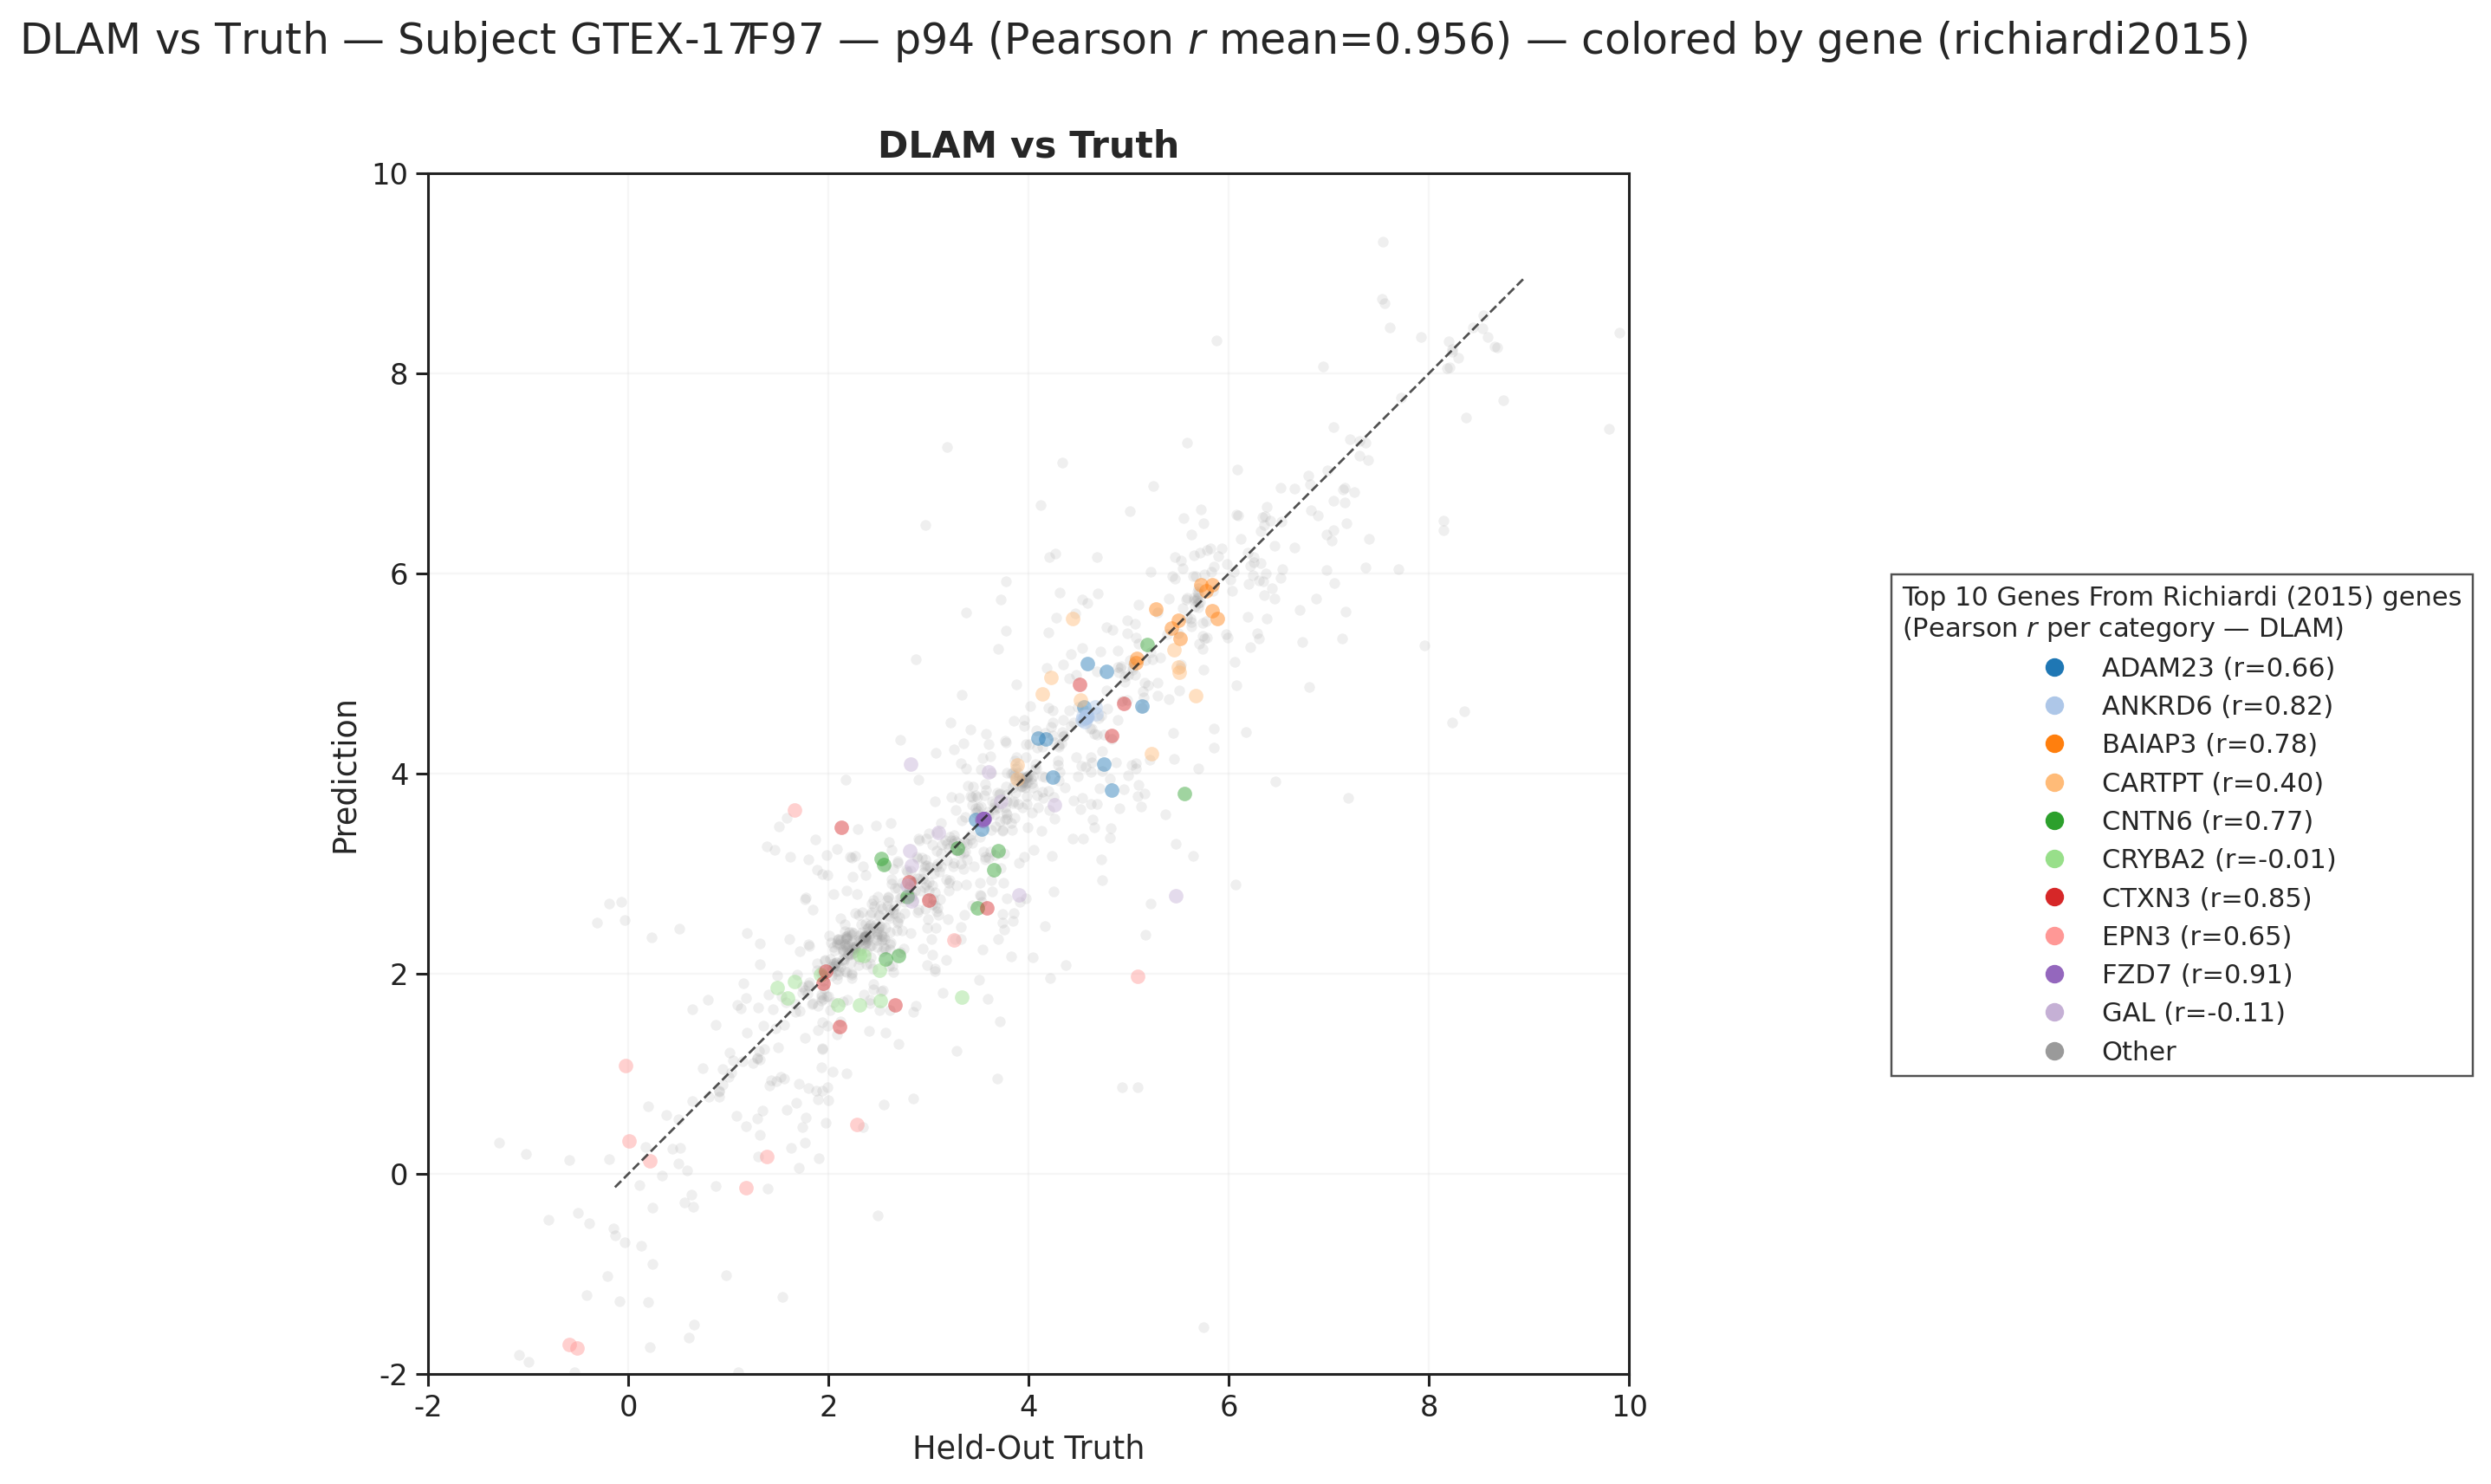

In [38]:
for _, row in pct_picks.iterrows():
    sub_view = _make_subview(row, ILLUSTRATIVE_GENE_LIST_HVG)
    fig, axes = plot_global_prediction_scatter(
        sub_view,
        color_by='gene',
        top_n=ILLUSTRATIVE_GENE_TOP_N,
        figsize=ILLUSTRATIVE_FIGSIZE_BC,
        point_size=ILLUSTRATIVE_POINT_SIZE_BC,
        annotate_metric_in_legend=ILLUSTRATIVE_ANNOTATE_METRIC is not None,
        annotation_metric=ILLUSTRATIVE_ANNOTATE_METRIC or 'pearson_r',
    )
    _suptitle(fig, row, f"colored by gene ({ILLUSTRATIVE_GENE_LIST_HVG})")


##### View C — focus gene isolated

Same 3 subjects + HVG subset, with `ILLUSTRATIVE_FOCUS_GENE` appended as a side panel: only that gene's points across regions, plus a goodness-of-fit line.


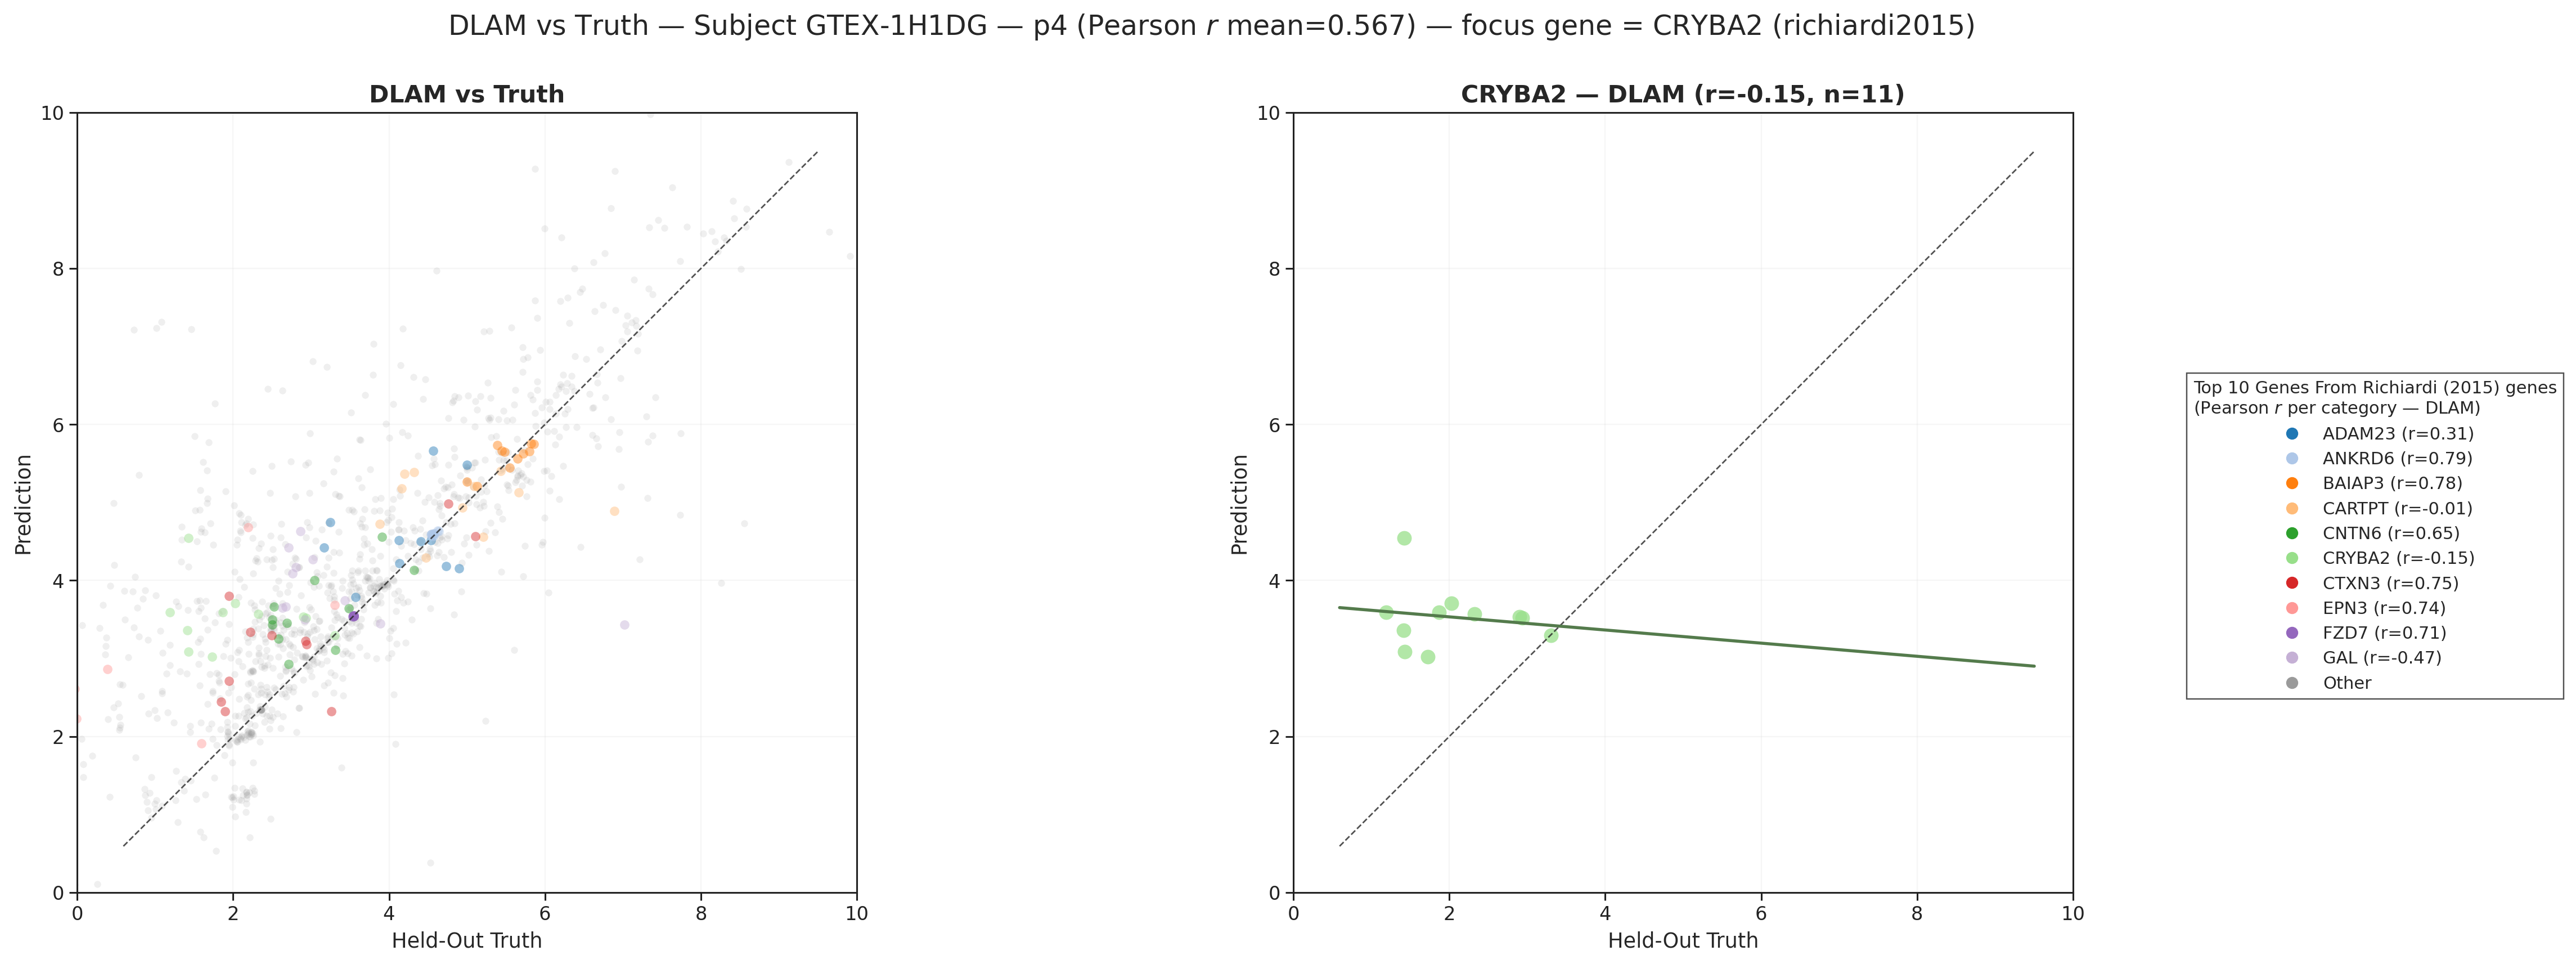

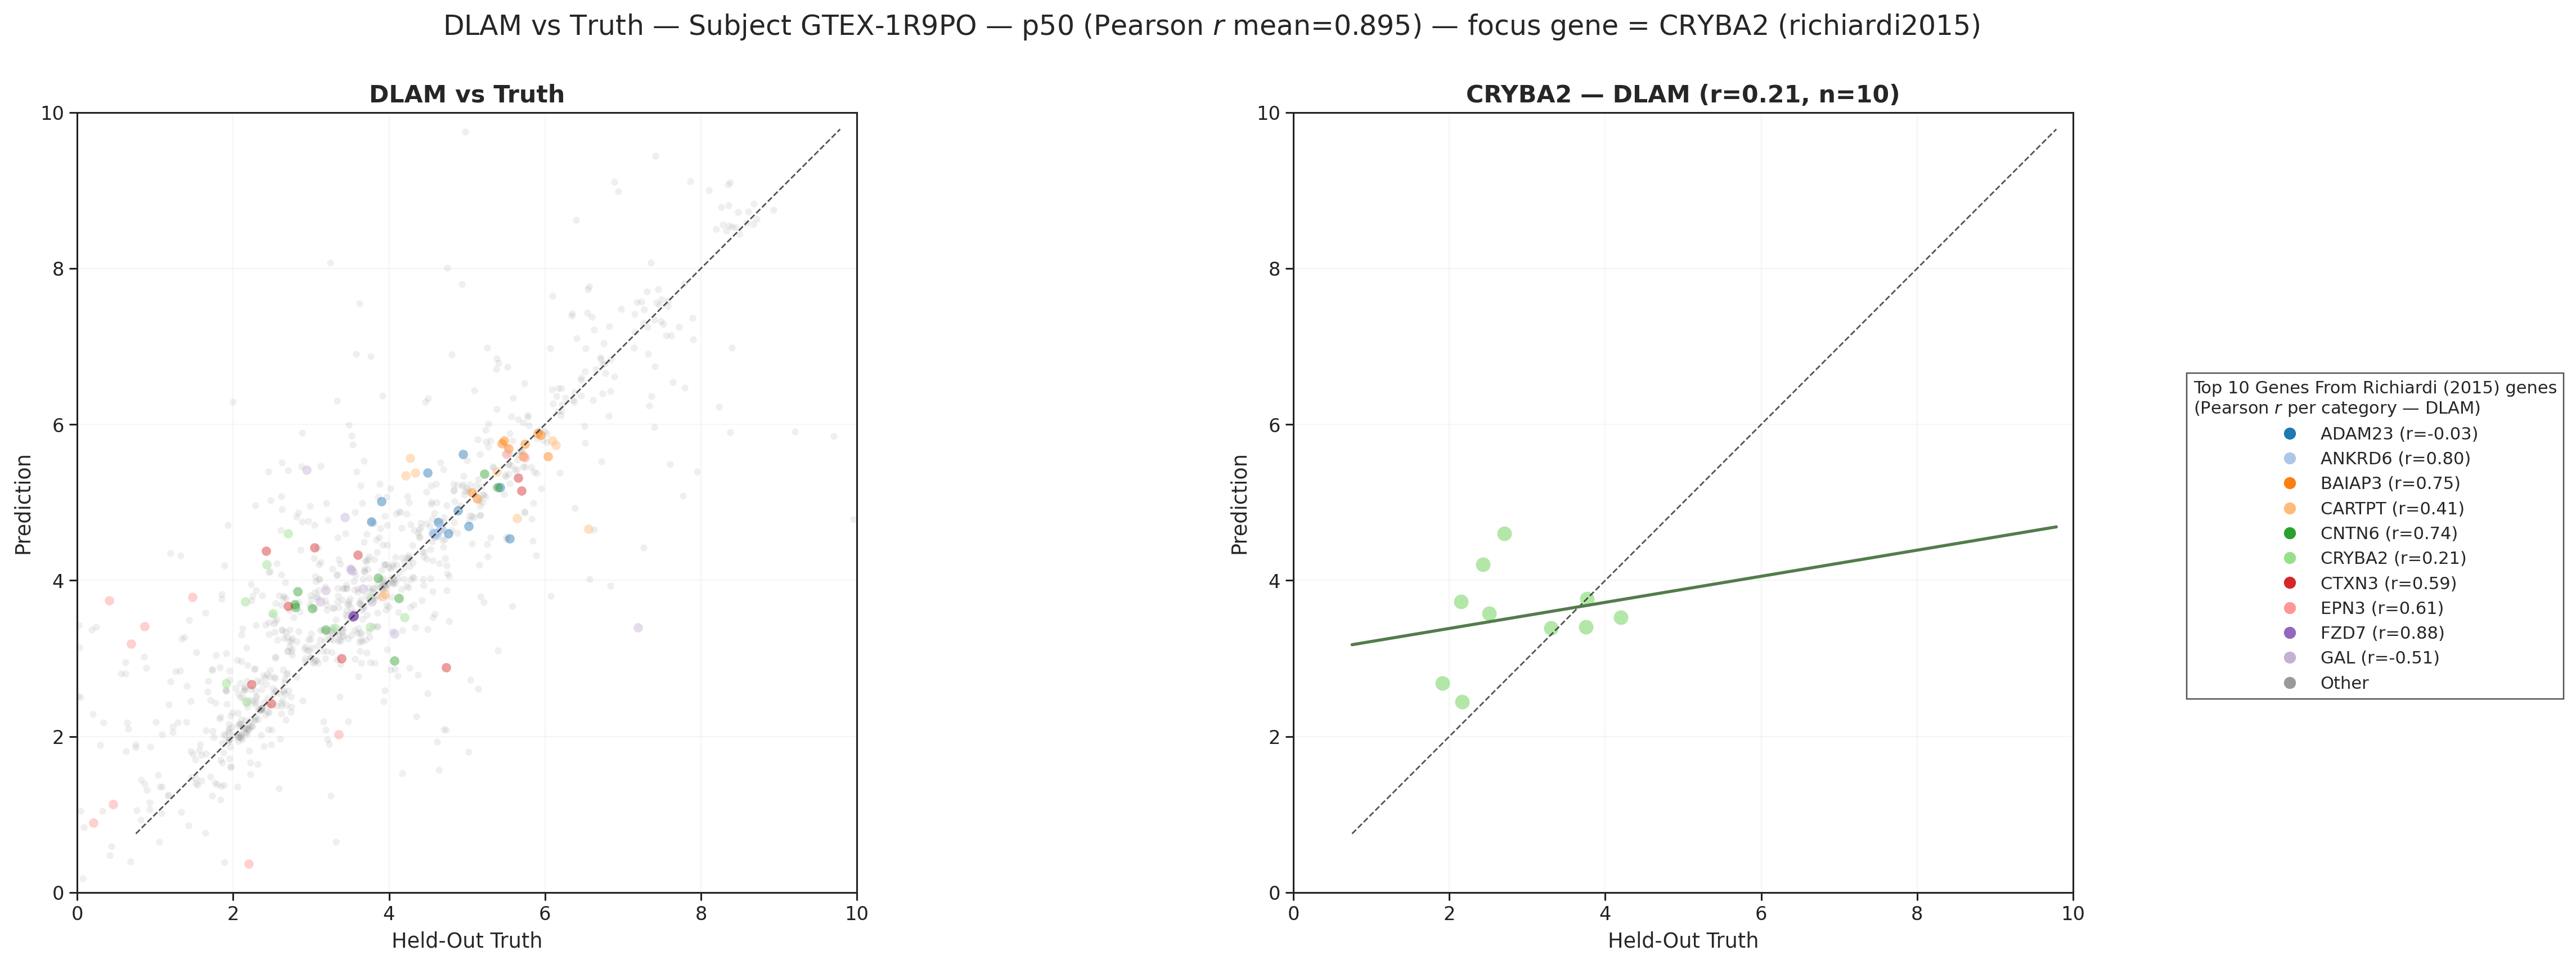

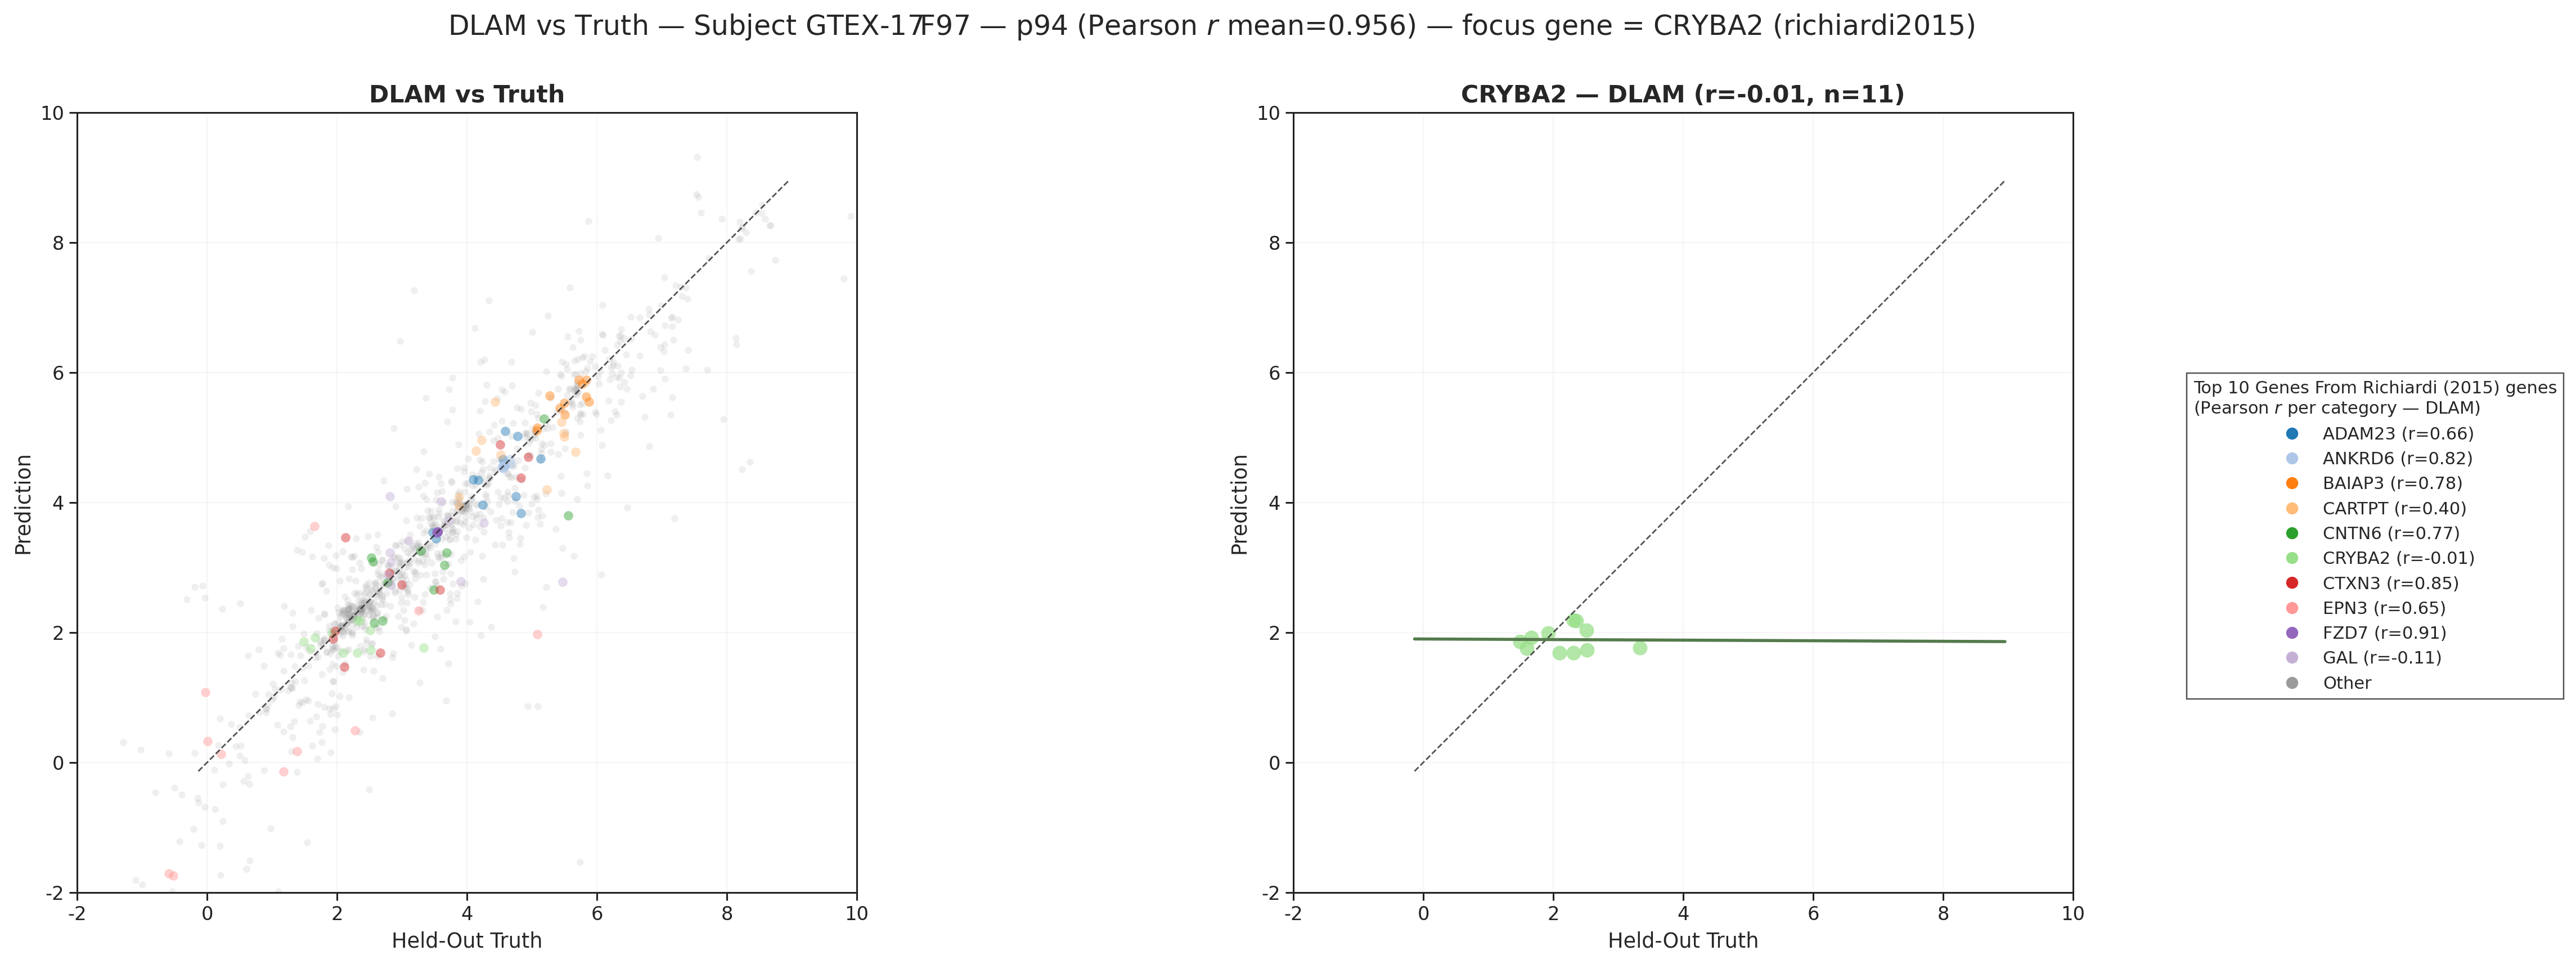

In [39]:
for _, row in pct_picks.iterrows():
    sub_view = _make_subview(row, ILLUSTRATIVE_GENE_LIST_HVG)
    fig, axes = plot_global_prediction_scatter(
        sub_view,
        color_by='gene',
        top_n=ILLUSTRATIVE_GENE_TOP_N,
        figsize=ILLUSTRATIVE_FIGSIZE_BC,
        point_size=ILLUSTRATIVE_POINT_SIZE_BC,
        annotate_metric_in_legend=ILLUSTRATIVE_ANNOTATE_METRIC is not None,
        annotation_metric=ILLUSTRATIVE_ANNOTATE_METRIC or 'pearson_r',
        isolate_stratum=ILLUSTRATIVE_FOCUS_GENE,
    )
    _suptitle(fig, row, f"focus gene = {ILLUSTRATIVE_FOCUS_GENE} ({ILLUSTRATIVE_GENE_LIST_HVG})")


##### View D — focus gene, colored by region

Same 3 subjects, isolated to `ILLUSTRATIVE_FOCUS_GENE`. The subview is built at full
gene scope and then subset to that one gene, so View D does not depend on the focus
gene being in `ILLUSTRATIVE_GENE_LIST_HVG`. Each point is one of the subject's covered
regions, colored by region — this shows how that single gene's prediction tracks truth
*across the subject's brain*. With only ~5-13 points per panel, the legend metric is
descriptive, not a headline number.


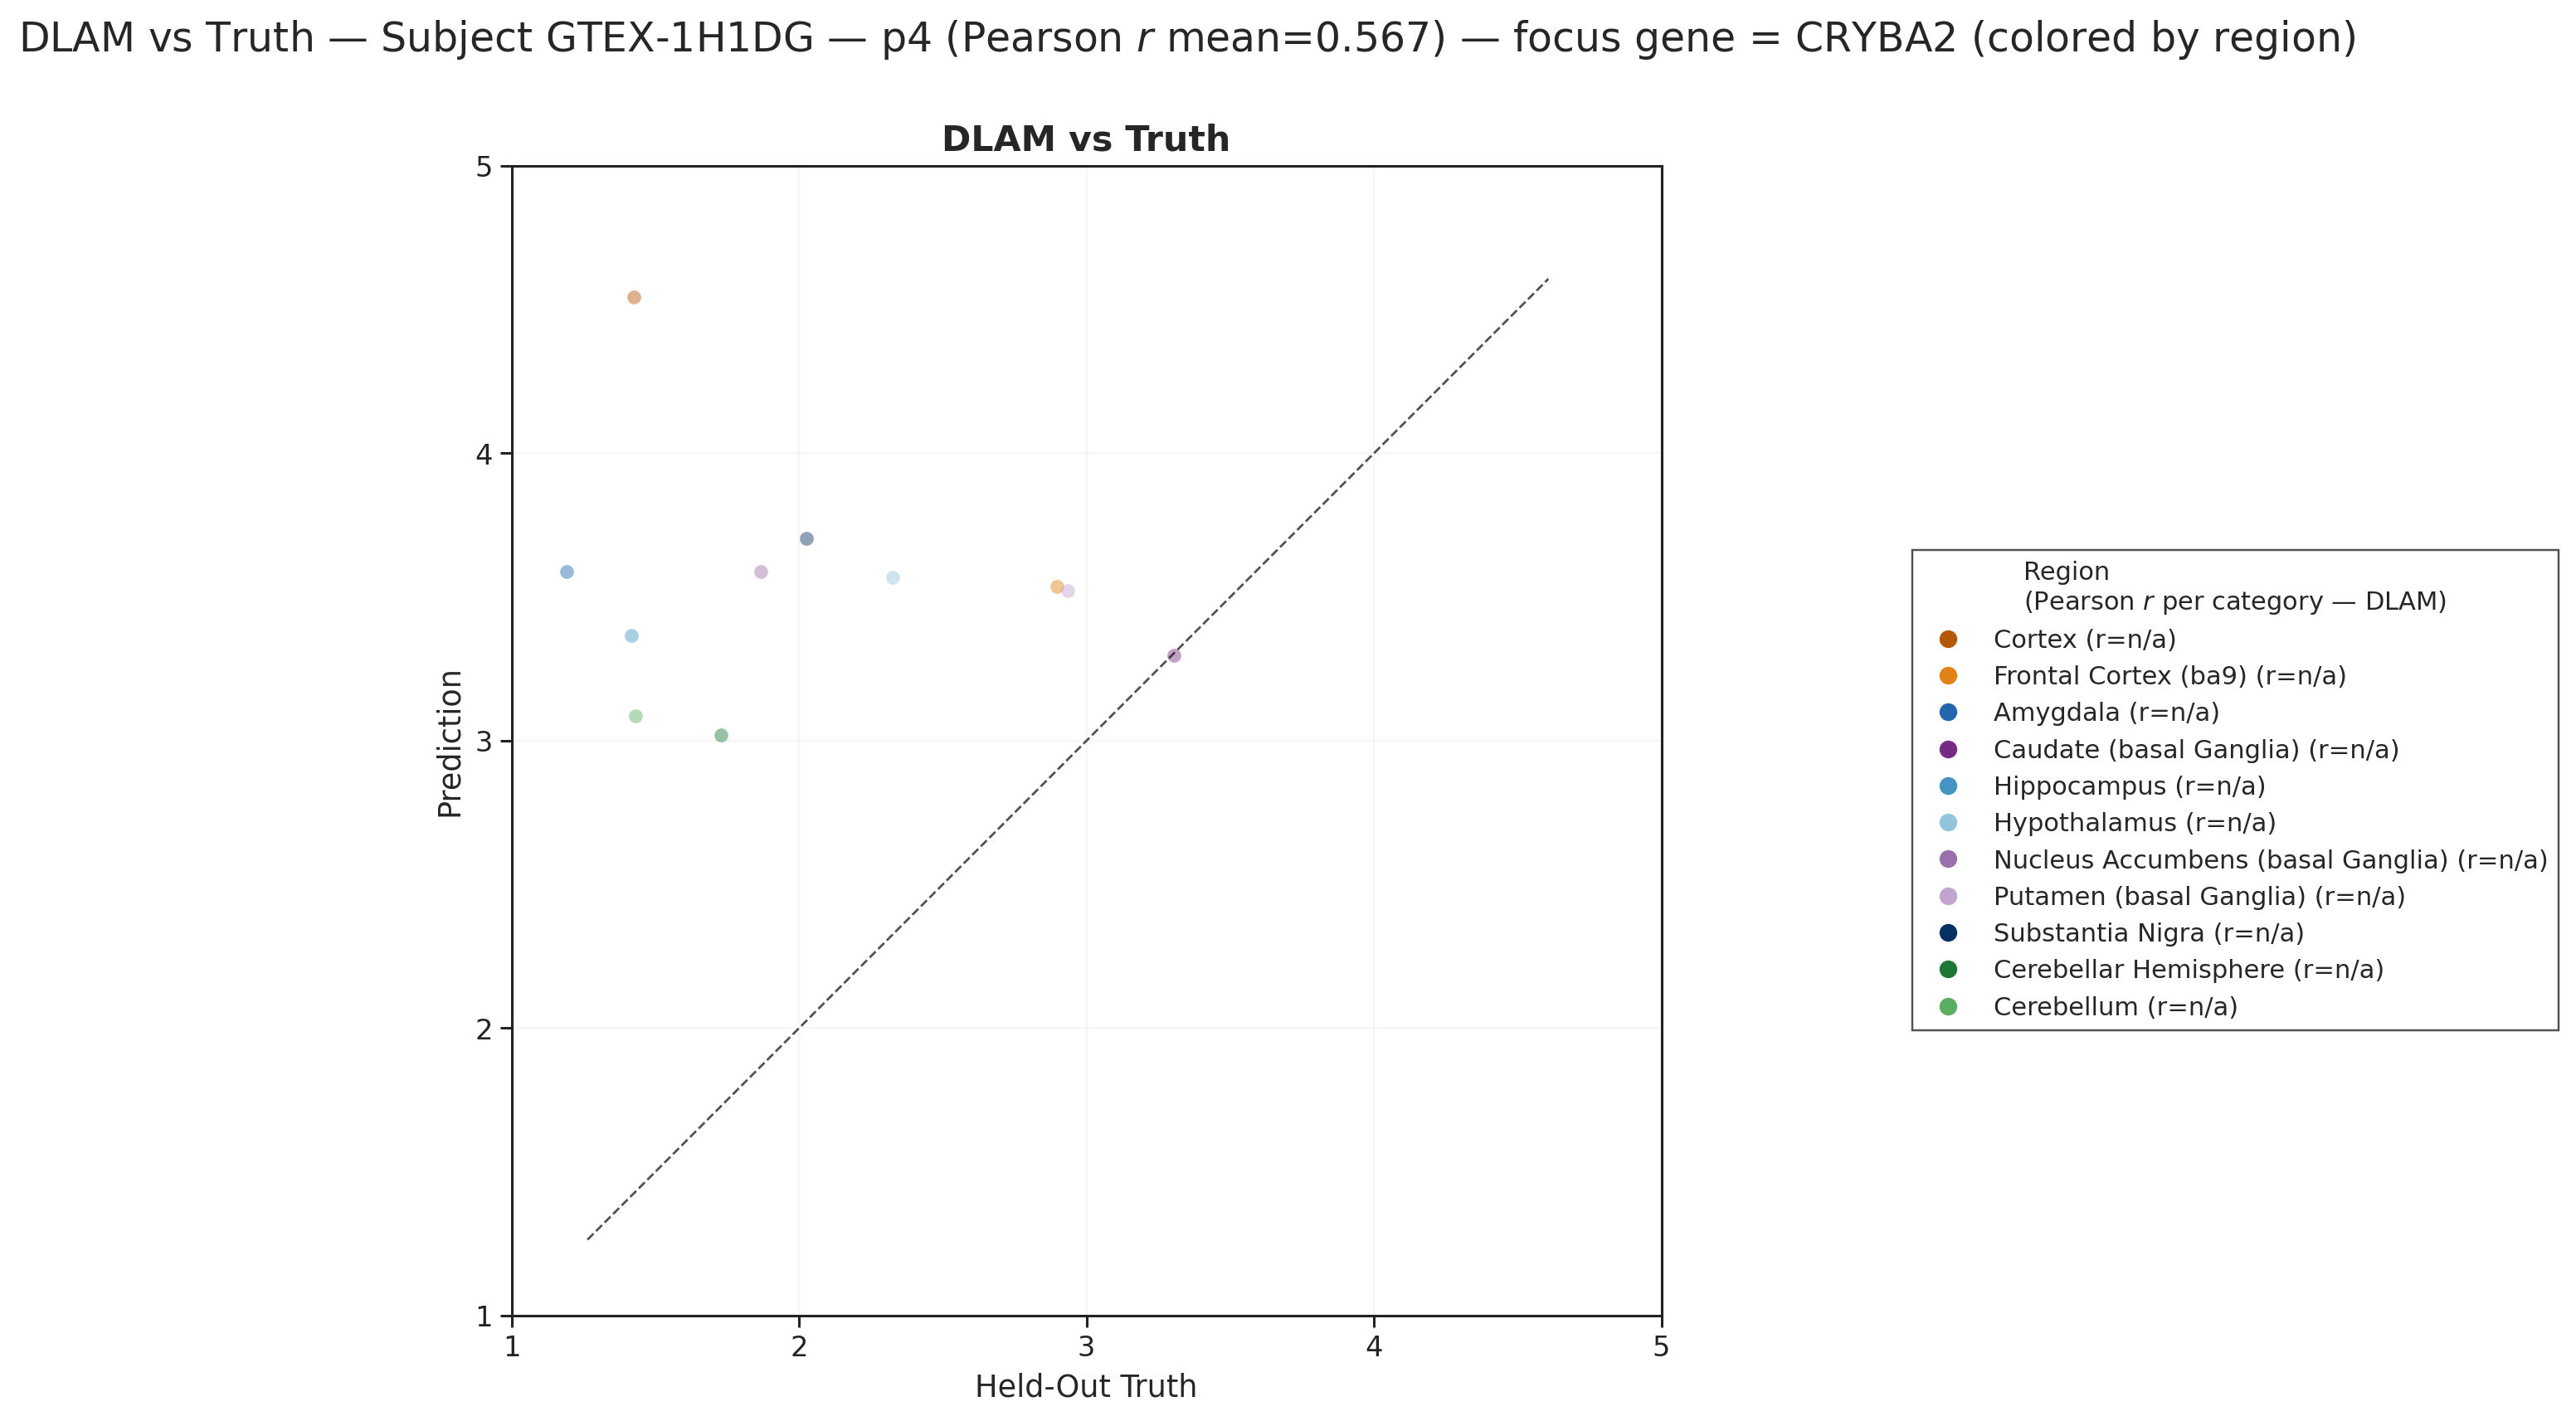

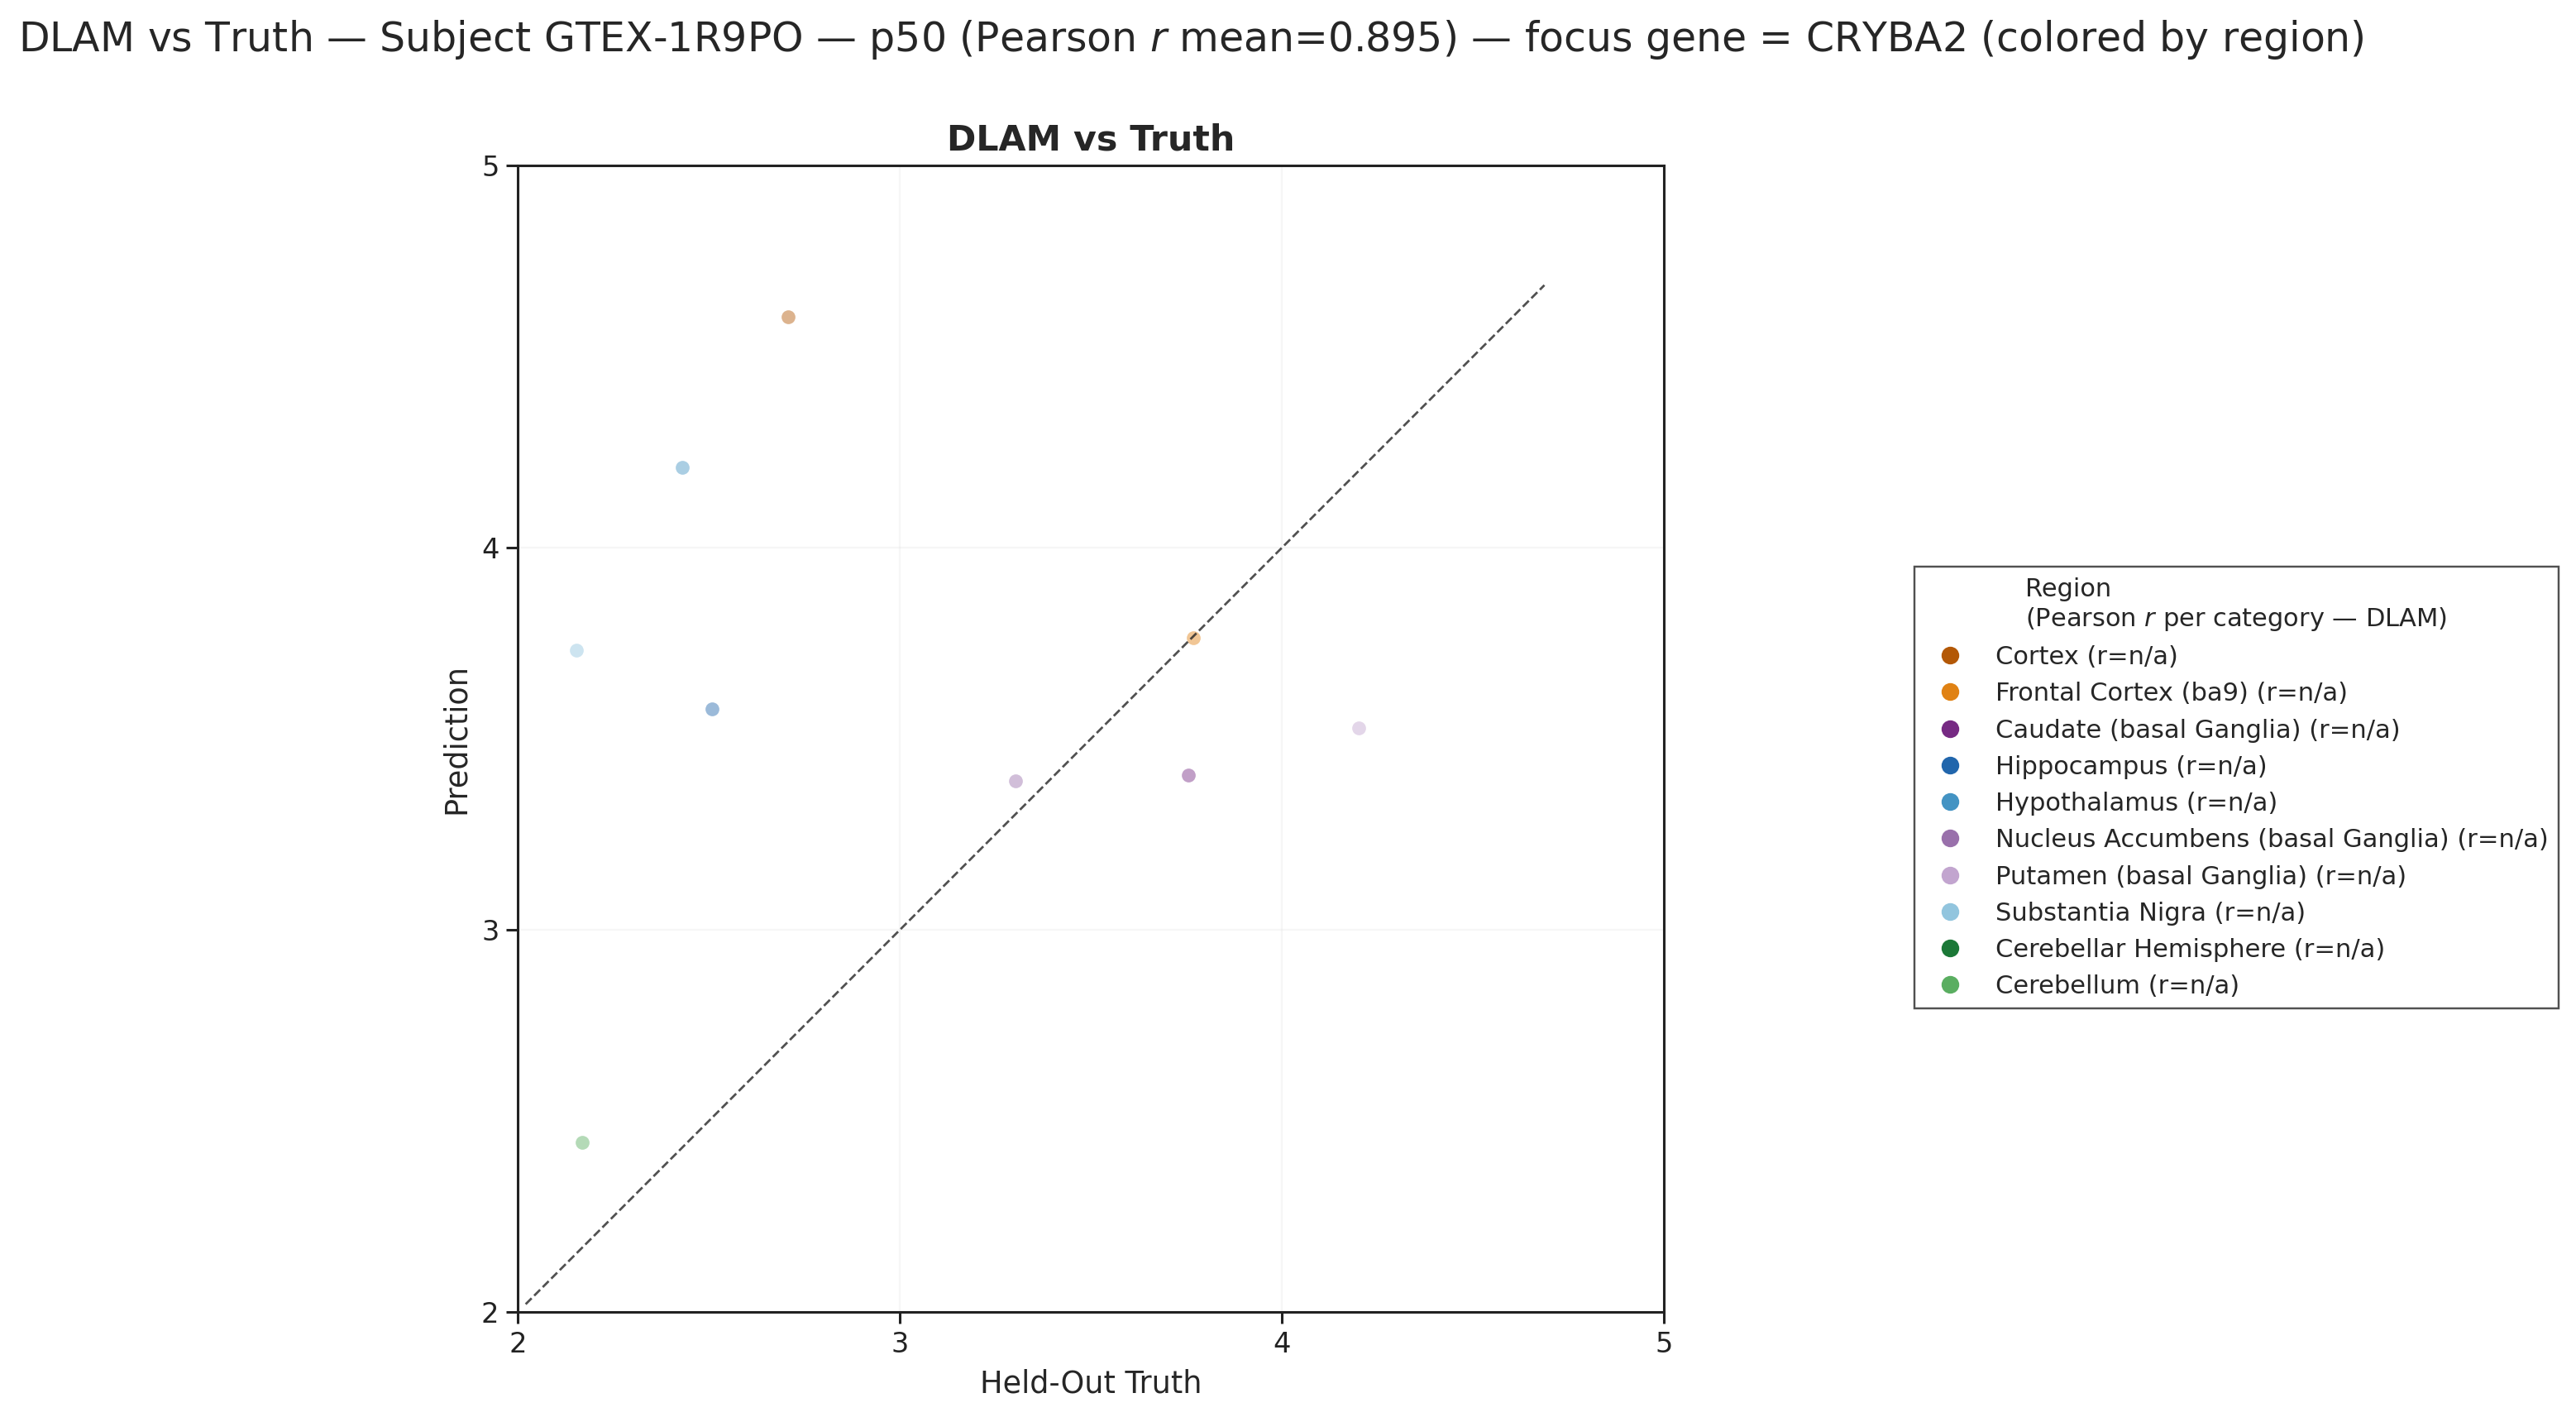

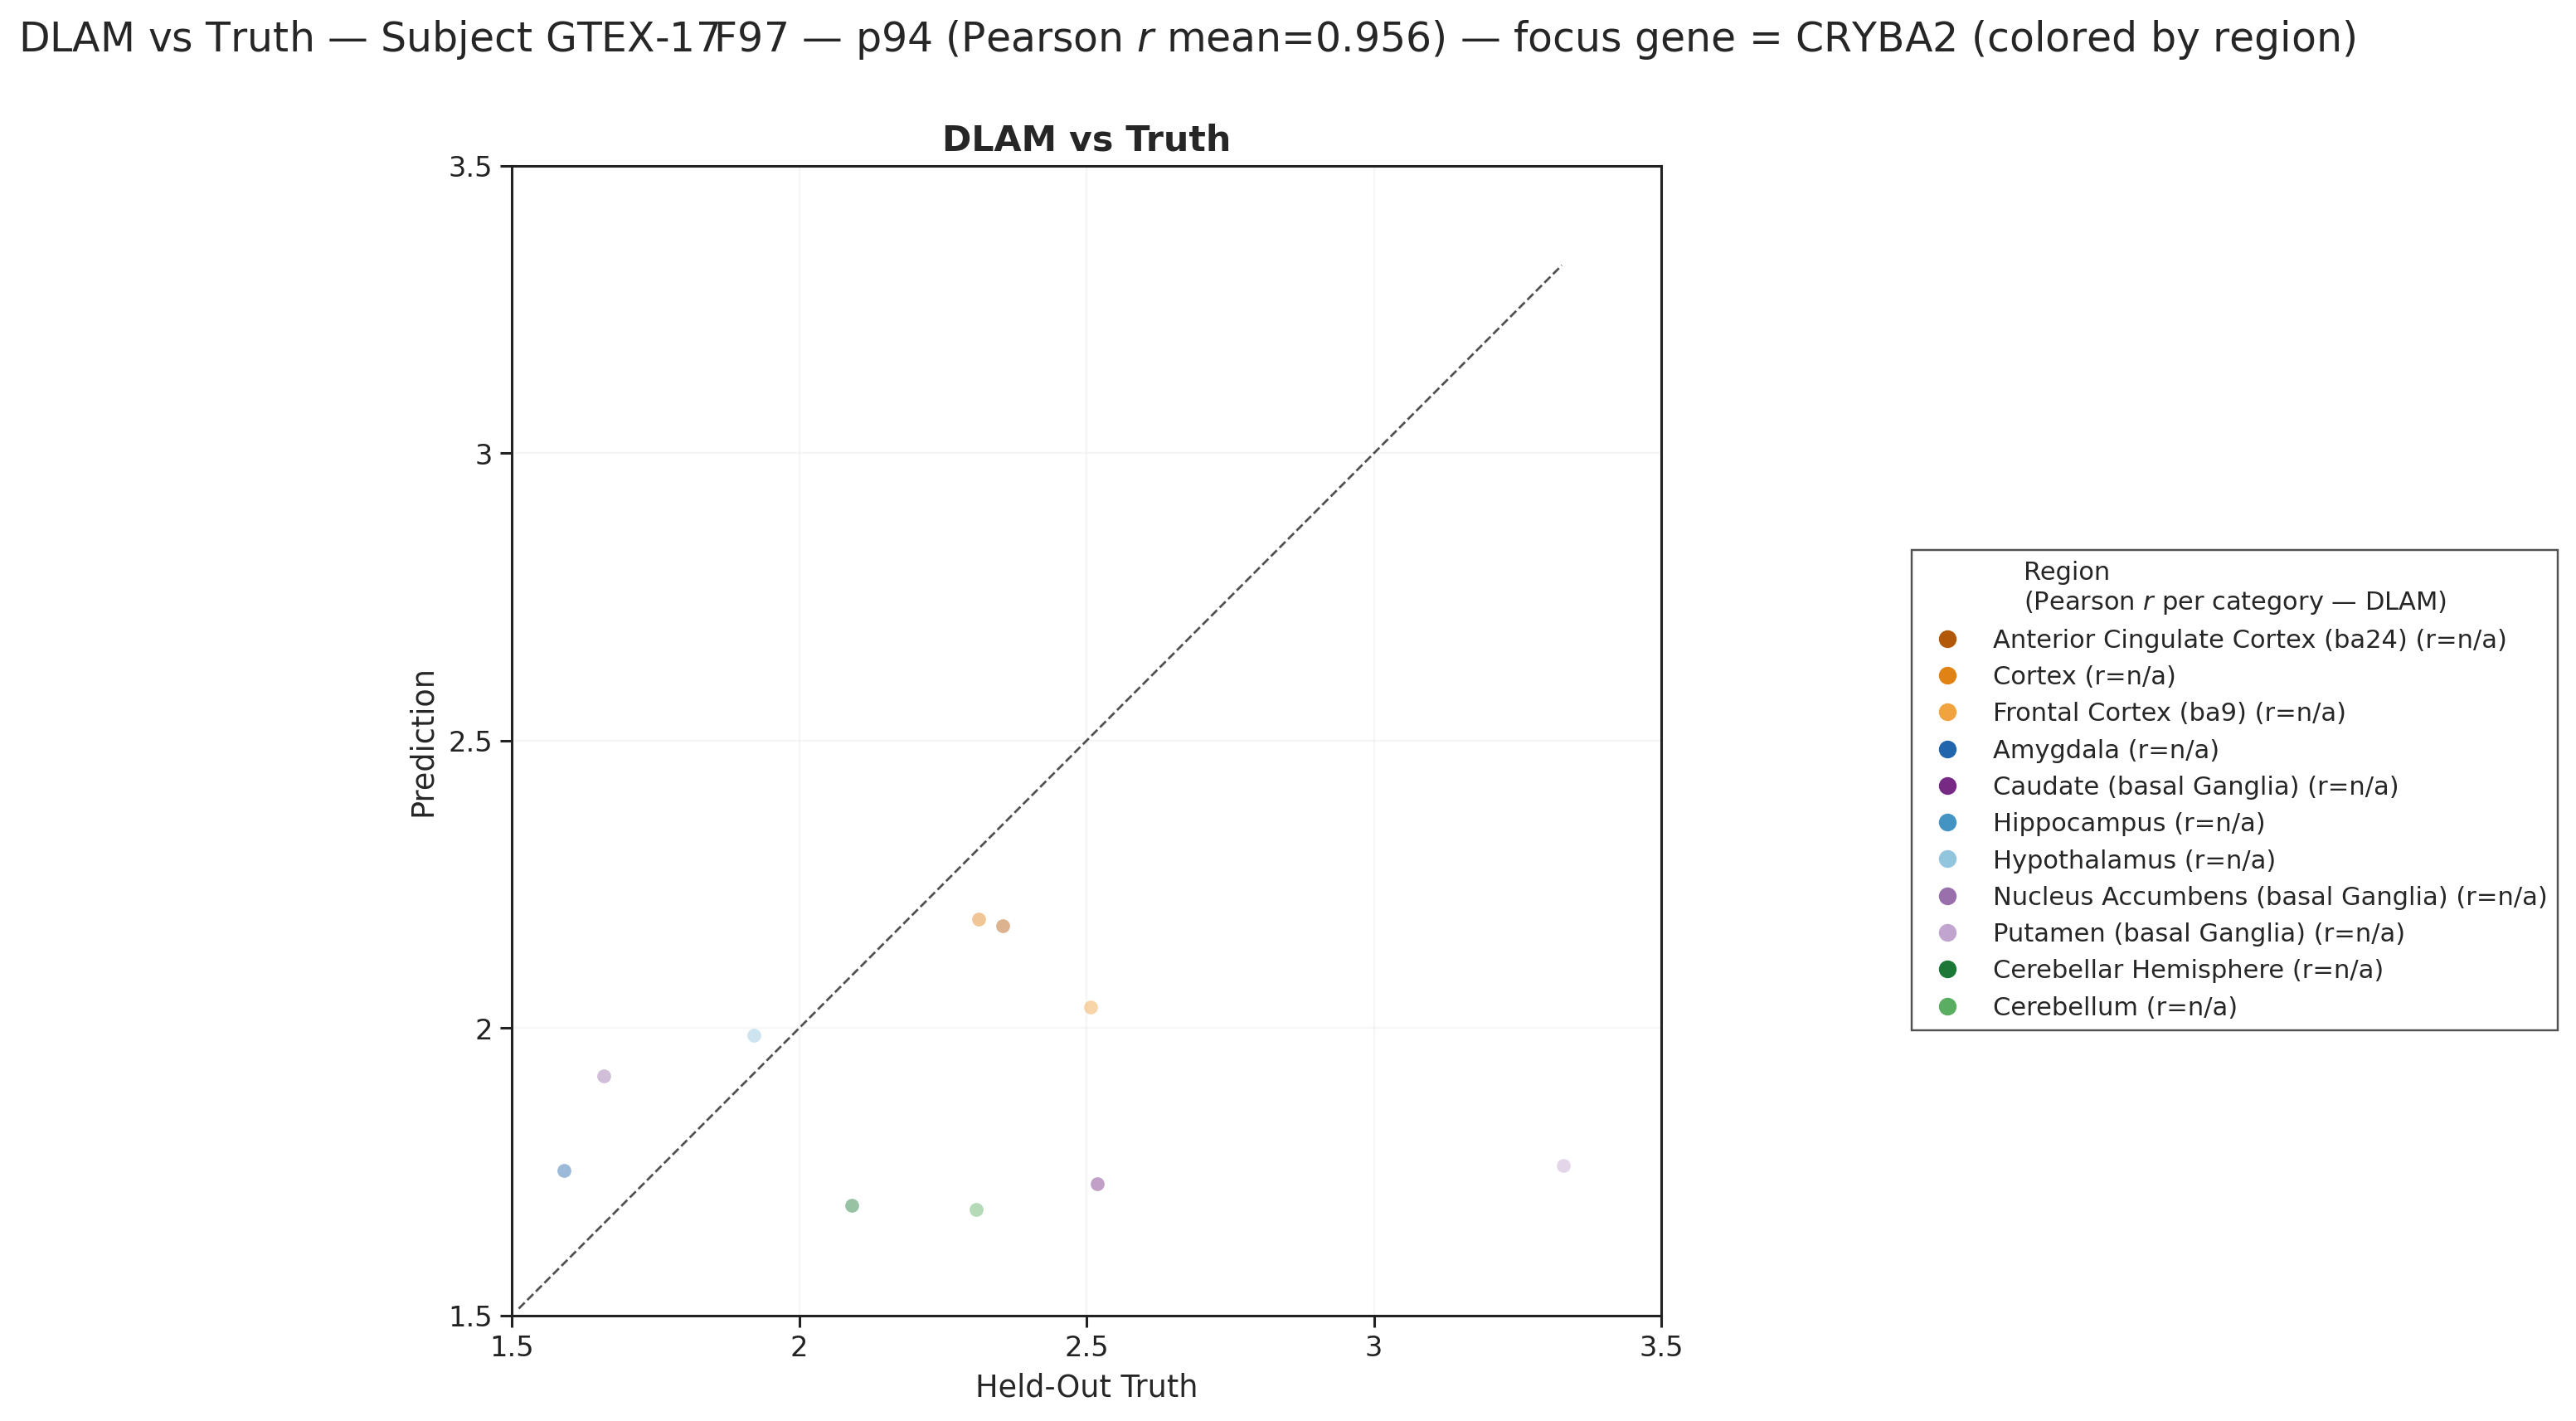

In [40]:
# View D isolates one gene (genes=[...]) instead of isolate_stratum, leaving
# color_by free to use 'region'. Subject is already isolated by _make_subview.
for _, row in pct_picks.iterrows():
    sub_view = _make_subview(row, None)              # full gene scope...
    fig, axes = plot_global_prediction_scatter(
        sub_view,
        genes=[ILLUSTRATIVE_FOCUS_GENE],             # ...isolate to one gene
        color_by='region',                          # ...colored by all regions
        figsize=ILLUSTRATIVE_FIGSIZE_BC,
        point_size=ILLUSTRATIVE_POINT_SIZE_BC,
        annotate_metric_in_legend=ILLUSTRATIVE_ANNOTATE_METRIC is not None,
        annotation_metric=ILLUSTRATIVE_ANNOTATE_METRIC or 'pearson_r',
    )
    _suptitle(fig, row, f"focus gene = {ILLUSTRATIVE_FOCUS_GENE} (colored by region)")


## Section 2 — Subject Specificity

Per LORO sample, two comparisons of the same prediction:

- **Self** — the subject's own truth at that region.
- **Other Subjects (mean)** — the mean of every other subject's truth at that same region.

Self ≫ Other ⇒ predictions are subject-specific. Self ≈ Other ⇒ predictions are converging on a regional template.


In [20]:
# Sections 2 & 3 — specificity config
SPECIFICITY_REGION_COL       = 'parcel_idx'
SHOW_SPATIAL_SPECIFICITY     = True


,model,n,median_self,median_other,median_delta
0,dlam,2869,0.900955,0.875542,0.027228
1,naive,2869,0.857786,0.863186,-0.000291
2,plam,2869,0.886765,0.870704,0.019658


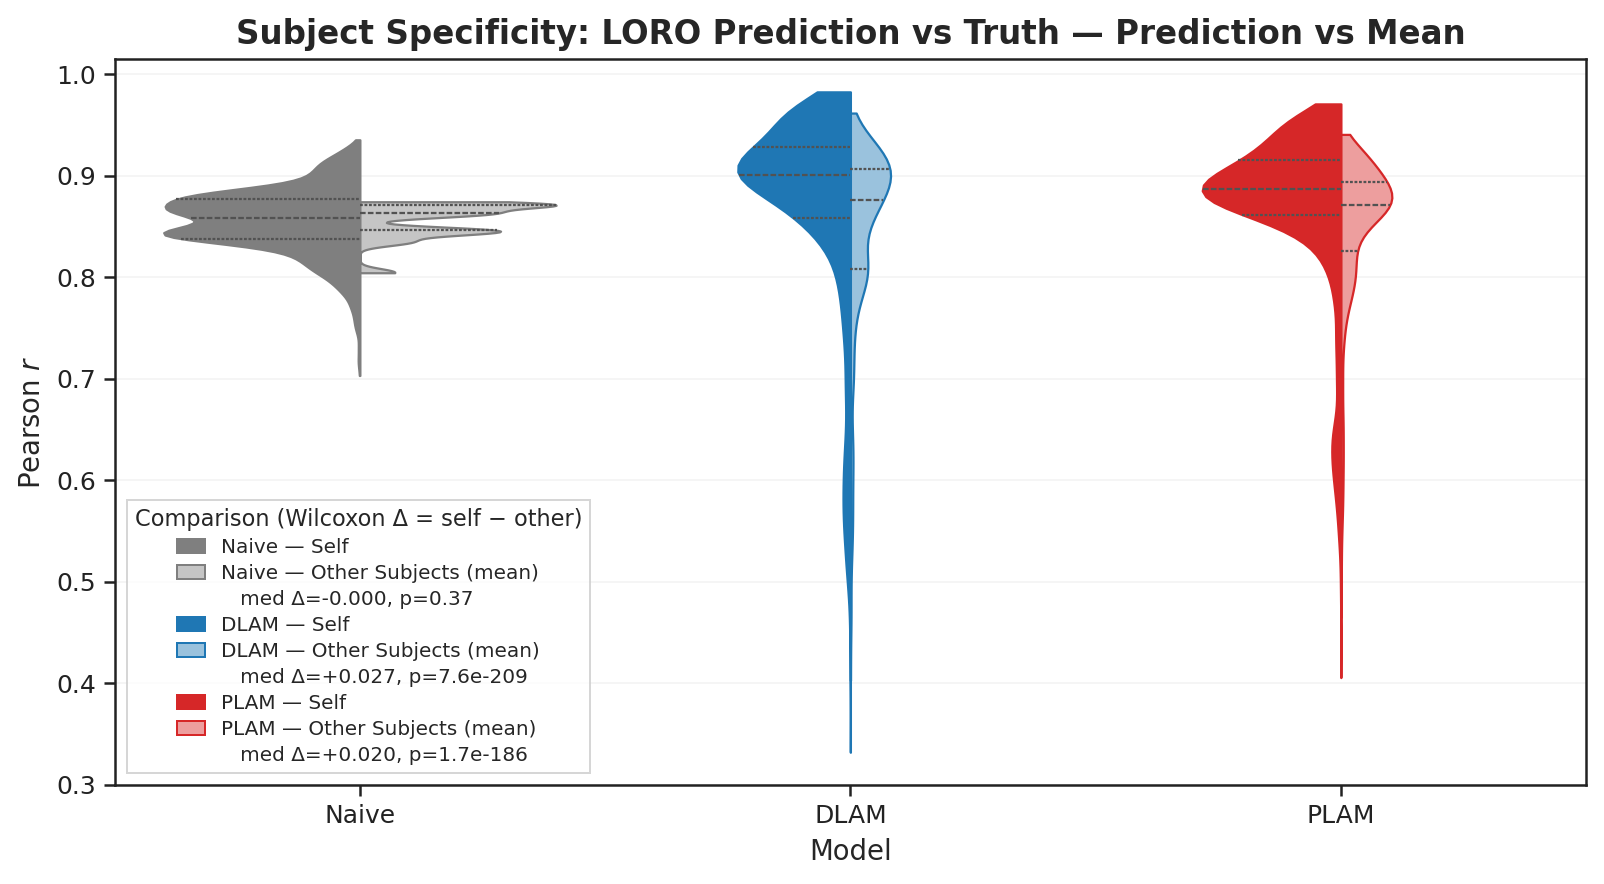

In [21]:
subject_specificity = compute_subject_specificity(
    subject_view,
    region_col=SPECIFICITY_REGION_COL,
    metric=DEFAULT_METRIC,
)

display(
    subject_specificity
    .groupby('model', as_index=False)
    .agg(
        n=('sim_self', 'size'),
        median_self=('sim_self', 'median'),
        median_other=('sim_other_mean', 'median'),
        median_delta=('delta', 'median'),
    )
)

fig, ax = plot_subject_specificity(subject_specificity)

## Section 3 — Spatial Specificity

Per LORO sample, two comparisons of the same prediction:

- **Self** — that *region*'s truth in the same subject.
- **Other Samples (within subject)** — mean of `k − 1` per-region metrics comparing the prediction to each *other* region's truth in the **same** subject.

Self ≫ Other ⇒ predictions are spatially differentiated within a brain. Self ≈ Other ⇒ a single subject-mean profile is being copied to every region (passes Section 2, fails here).


,model,n,median_self,median_other_region,median_delta
0,dlam,2869,0.900955,0.890059,0.013418
1,naive,2869,0.857786,0.823225,0.037237
2,plam,2869,0.886765,0.874040,0.017240


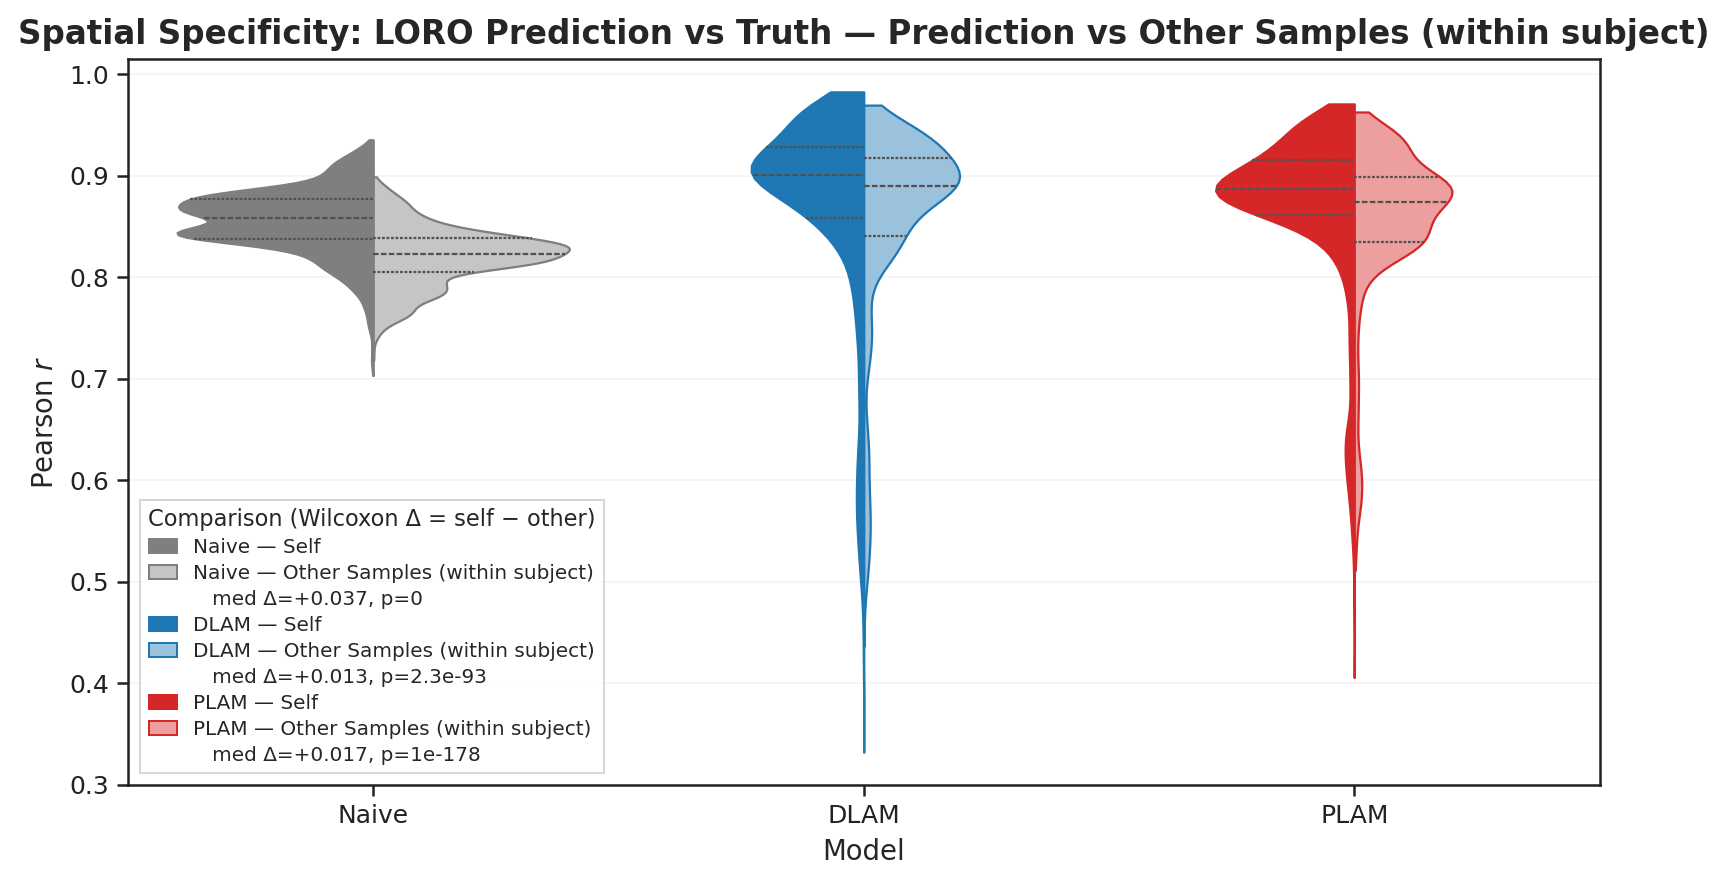

In [22]:
if SHOW_SPATIAL_SPECIFICITY:
    spatial_specificity = compute_spatial_specificity(
        subject_view,
        metric=DEFAULT_METRIC,
        region_col=SPECIFICITY_REGION_COL,
    )
    display(
        spatial_specificity
        .groupby('model', as_index=False)
        .agg(
            n=('sim_self', 'size'),
            median_self=('sim_self', 'median'),
            median_other_region=('sim_other_region_mean', 'median'),
            median_delta=('delta', 'median'),
        )
    )
    fig, ax = plot_spatial_specificity(spatial_specificity)